In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

print("Graphene notebook running on Kohn!")
print(np.__version__)

Graphene notebook running on Kohn!
1.23.5


In [2]:
import numpy as np
import matplotlib.pyplot as plt

Part A — Static graphene device and leads

In [3]:
# ============================================================
# PART A — STATIC GRAPHENE DEVICE AND LEADS
# Cell A1: Imports and shared parameters
# ============================================================

# -----------------------------
# Energy unit
# -----------------------------
# All energies are measured in units of graphene hopping gamma.
# Physical graphene: gamma ≈ 2.7 eV.
gamma = 1.0

# -----------------------------
# ZGNR geometry
# -----------------------------
Ny = 29                 # ribbon width; one unit cell has 2*Ny atoms
N_orb = 2 * Ny          # number of orbitals per lead/device slice

# Number of longitudinal unit cells in the finite irradiated region.
#
# Nx = 30 is motivated by the finite-length geometry used in the paper,

Nx = 30

# Total number of orbitals in the central graphene region
N_device = Nx * N_orb

# -----------------------------
# Numerical tolerances
# -----------------------------
eta = 1e-8              # small imaginary broadening for retarded GFs

print("ZGNR width Ny                  =", Ny)
print("Atoms (Orbitals) per longitudinal cell =", N_orb)
print("Number of device cells Nx      =", Nx)
print("Total device orbitals          =", N_device)

ZGNR width Ny                  = 29
Atoms (Orbitals) per longitudinal cell = 58
Number of device cells Nx      = 30
Total device orbitals          = 1740


In [4]:
# ============================================================
# Cell A2: Static ZGNR unit-cell Hamiltonian
# ============================================================

def zgnr_unit_cell(Ny, gamma=1.0):
    """
    Construct the static nearest-neighbor tight-binding matrices
    for a zigzag graphene nanoribbon.

    Returns
    -------
    H00 : ndarray
        Intracell Hamiltonian of one longitudinal ZGNR slice.

    H01 : ndarray
        Coupling from one longitudinal slice to the next.

    Notes
    -----
    One slice contains:
        A_0, B_0, A_1, B_1, ..., A_(Ny-1), B_(Ny-1)

    so its dimension is 2*Ny.
    """

    n_orb = 2 * Ny

    H00 = np.zeros((n_orb, n_orb), dtype=complex)
    H01 = np.zeros((n_orb, n_orb), dtype=complex)

    def A(j):
        """Index of sublattice-A orbital at transverse position j."""
        return 2 * j

    def B(j):
        """Index of sublattice-B orbital at transverse position j."""
        return 2 * j + 1

    # --------------------------------------------------------
    # Nearest-neighbor bonds inside one longitudinal unit cell
    # --------------------------------------------------------

    # A_j <-> B_j
    for j in range(Ny):
        H00[A(j), B(j)] = -gamma
        H00[B(j), A(j)] = -gamma

    # B_j <-> A_(j+1)
    for j in range(Ny - 1):
        H00[A(j + 1), B(j)] = -gamma
        H00[B(j), A(j + 1)] = -gamma

    # --------------------------------------------------------
    # Coupling between neighboring longitudinal unit cells
    # --------------------------------------------------------

    for j in range(Ny):
        H01[A(j), B(j)] = -gamma

    return H00, H01


# Construct the matrices only once
H00, H01 = zgnr_unit_cell(Ny, gamma)

print("H00 shape =", H00.shape)
print("H01 shape =", H01.shape)

print(
    "Hermiticity error of H00 =",
    np.linalg.norm(H00 - H00.conj().T)
)

H00 shape = (58, 58)
H01 shape = (58, 58)
Hermiticity error of H00 = 0.0


In [5]:
# ============================================================
# Cell A3: Finite central graphene region
# ============================================================

def build_finite_zgnr(H00, H01, Nx):
    """
    Construct a finite ZGNR consisting of Nx longitudinal slices.

    Parameters
    ----------
    H00 : ndarray
        Intracell Hamiltonian.

    H01 : ndarray
        Coupling from slice x to slice x+1.

    Nx : int
        Number of longitudinal slices.

    Returns
    -------
    H_device : ndarray
        Static Hamiltonian of the finite central region.
    """

    n_orb = H00.shape[0]
    n_total = Nx * n_orb

    H_device = np.zeros(
        (n_total, n_total),
        dtype=complex
    )

    # Intracell blocks
    for x in range(Nx):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        H_device[sl_x, sl_x] = H00

    # Couplings between neighboring longitudinal slices
    for x in range(Nx - 1):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        sl_next = slice(
            (x + 1) * n_orb,
            (x + 2) * n_orb
        )

        H_device[sl_x, sl_next] = H01
        H_device[sl_next, sl_x] = H01.conj().T

    return H_device


H_device_static = build_finite_zgnr(
    H00,
    H01,
    Nx
)

# ------------------------------------------------------------
# Contact orbitals
# ------------------------------------------------------------
# The first longitudinal slice couples to the left lead.
left_contact = np.arange(
    0,
    N_orb
)

# The last longitudinal slice couples to the right lead.
right_contact = np.arange(
    (Nx - 1) * N_orb,
    Nx * N_orb
)

print("Static device shape =", H_device_static.shape)

print(
    "Device Hermiticity error =",
    np.linalg.norm(
        H_device_static
        - H_device_static.conj().T
    )
)

print("Number of left-contact orbitals  =", len(left_contact))
print("Number of right-contact orbitals =", len(right_contact))

Static device shape = (1740, 1740)
Device Hermiticity error = 0.0
Number of left-contact orbitals  = 58
Number of right-contact orbitals = 58


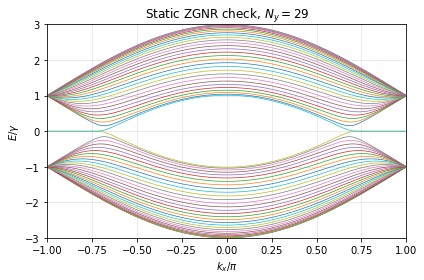

In [6]:
# ============================================================
# Cell A4: Optional check of the static ZGNR band structure
# ============================================================

def static_bloch_hamiltonian(k, H00, H01):
    """
    Static Bloch Hamiltonian of an infinite ZGNR.

    k is the dimensionless longitudinal Bloch momentum.
    """

    return (
        H00
        + H01 * np.exp(1j * k)
        + H01.conj().T * np.exp(-1j * k)
    )


Nk_check = 300

k_values = np.linspace(
    -np.pi,
    np.pi,
    Nk_check,
    endpoint=False
)

static_bands = np.zeros(
    (Nk_check, N_orb)
)

for ik, k in enumerate(k_values):

    Hk = static_bloch_hamiltonian(
        k,
        H00,
        H01
    )

    static_bands[ik] = np.linalg.eigvalsh(Hk)


plt.figure(figsize=(6, 4))

for band_index in range(N_orb):

    plt.plot(
        k_values / np.pi,
        static_bands[:, band_index],
        lw=0.7
    )

plt.xlabel(r"$k_x/\pi$")
plt.ylabel(r"$E/\gamma$")
plt.title(rf"Static ZGNR check, $N_y={Ny}$")

plt.xlim(-1, 1)
plt.ylim(-3, 3)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Part B — Driven graphene Floquet system

In [7]:
# ============================================================
# PART B — DRIVEN GRAPHENE FLOQUET SYSTEM
# Cell B1: Light and Floquet parameters
# ============================================================

# Circularly polarized light
z = 0.5                  # dimensionless light amplitude
omega = 3.0              # photon energy hbar*omega in units of gamma
#Here omega represents ℏω in units of γ, not an angular frequency in inverse second

# Floquet truncation
Nph = 1                  # begin with 1 for testing
sectors = np.arange(-Nph, Nph + 1)

# Number of phase points used for numerical Fourier integration
N_phase = 200

# Small imaginary part in retarded Green functions
eta_floquet = 1e-6

# Floquet dimensions
Ndev = Nx * N_orb
NF = len(sectors) * Ndev

print("Light amplitude z       =", z)
print("Photon energy hbar*w    =", omega, "gamma")
print("Floquet sectors         =", sectors)
print("Static device dimension =", Ndev)
print("Floquet dimension       =", NF)

Light amplitude z       = 0.5
Photon energy hbar*w    = 3.0 gamma
Floquet sectors         = [-1  0  1]
Static device dimension = 1740
Floquet dimension       = 5220


In [8]:
# ============================================================
# Cell B2: Driven ZGNR unit-cell blocks
# ============================================================

def driven_zgnr_unit_cell(phi, Ny, gamma=1.0, z=0.5):
    """
    Construct the time-dependent ZGNR blocks at phase phi = omega*t.

    Parameters
    ----------
    phi : float
        Dimensionless driving phase omega*t.

    Ny : int
        Ribbon width parameter.

    gamma : float
        Nearest-neighbor hopping.

    z : float
        Dimensionless circular-light amplitude.

    Returns
    -------
    H00_phi : ndarray
        Driven intracell Hamiltonian.

    H01_phi : ndarray
        Driven coupling from one longitudinal cell to the next.
    """

    n_orb = 2 * Ny

    H00_phi = np.zeros((n_orb, n_orb), dtype=complex)
    H01_phi = np.zeros((n_orb, n_orb), dtype=complex)

    def A(j):
        return 2 * j

    def B(j):
        return 2 * j + 1

    # Dimensionless vector-potential direction
    Ax = np.cos(phi)
    Ay = np.sin(phi)

    def peierls_phase(dx, dy):
        """
        exp[i 2z A(phi).r_ij]
        """
        return np.exp(
            1j * 2.0 * z * (Ax * dx + Ay * dy)
        )

    # Three nearest-neighbor graphene bond directions
    d1 = (0.0, 1.0)
    d2 = (np.sqrt(3.0) / 2.0, -0.5)
    d3 = (-np.sqrt(3.0) / 2.0, -0.5)

    # Bond type 1: A_j <-> B_j inside one cell
    hopping_1 = -gamma * peierls_phase(*d1)

    for j in range(Ny):
        H00_phi[A(j), B(j)] += hopping_1
        H00_phi[B(j), A(j)] += np.conj(hopping_1)

    # Bond type 2: B_j <-> A_(j+1) inside one cell
    hopping_2 = -gamma * peierls_phase(*d2)

    for j in range(Ny - 1):
        H00_phi[A(j + 1), B(j)] += hopping_2
        H00_phi[B(j), A(j + 1)] += np.conj(hopping_2)

    # Bond type 3: coupling to the next longitudinal cell
    hopping_3 = -gamma * peierls_phase(*d3)

    for j in range(Ny):
        H01_phi[A(j), B(j)] += hopping_3

    return H00_phi, H01_phi

#This is the essential 2D feature: the Peierls phase depends on the direction of each graphene bond

In [9]:
# ============================================================
# Cell B3: Finite driven ZGNR Hamiltonian H(phi)
# ============================================================

def build_driven_device(phi, Nx, Ny, gamma=1.0, z=0.5):
    """
    Construct the finite irradiated graphene Hamiltonian H(phi).
    """

    H00_phi, H01_phi = driven_zgnr_unit_cell(
        phi=phi,
        Ny=Ny,
        gamma=gamma,
        z=z
    )

    n_orb = 2 * Ny
    n_device = Nx * n_orb

    H_phi = np.zeros(
        (n_device, n_device),
        dtype=complex
    )

    # Intracell blocks
    for x in range(Nx):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        H_phi[sl_x, sl_x] = H00_phi

    # Coupling between adjacent longitudinal cells
    for x in range(Nx - 1):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        sl_next = slice(
            (x + 1) * n_orb,
            (x + 2) * n_orb
        )

        H_phi[sl_x, sl_next] = H01_phi
        H_phi[sl_next, sl_x] = H01_phi.conj().T

    return H_phi

In [10]:
# Check Hermiticity at one arbitrary driving phase

H_test = build_driven_device(
    phi=0.37,
    Nx=Nx,
    Ny=Ny,
    gamma=gamma,
    z=z
)

print(
    "Hermiticity error of H(phi) =",
    np.linalg.norm(H_test - H_test.conj().T)
)

Hermiticity error of H(phi) = 0.0


In [11]:
# ============================================================
# Cell B4: Fourier components H_m of the driven device
# ============================================================

def device_fourier_components(
    Nx,
    Ny,
    gamma=1.0,
    z=0.5,
    Mmax=2,
    N_phase=200
):
    """
    Numerically calculate H_m for -Mmax <= m <= Mmax.
    """

    n_device = Nx * 2 * Ny

    phases = np.linspace(
        0.0,
        2.0 * np.pi,
        N_phase,
        endpoint=False
    )

    H_fourier = {
        m: np.zeros(
            (n_device, n_device),
            dtype=complex
        )
        for m in range(-Mmax, Mmax + 1)
    }

    for phi in phases:

        H_phi = build_driven_device(
            phi=phi,
            Nx=Nx,
            Ny=Ny,
            gamma=gamma,
            z=z
        )

        for m in H_fourier:

            H_fourier[m] += (
                H_phi * np.exp(-1j * m * phi)
            )

    for m in H_fourier:
        H_fourier[m] /= N_phase

    return H_fourier

In [12]:
# We need differences m-n up to 2*Nph

H_fourier = device_fourier_components(
    Nx=Nx,
    Ny=Ny,
    gamma=gamma,
    z=z,
    Mmax=2 * Nph,
    N_phase=N_phase
)

print("Calculated Fourier orders:")
print(sorted(H_fourier.keys()))

Calculated Fourier orders:
[-2, -1, 0, 1, 2]


In [13]:
#Fourier consistency check For a Hermitian H(t)

for m in range(1, 2 * Nph + 1):

    error = np.linalg.norm(
        H_fourier[-m]
        - H_fourier[m].conj().T
    )

    print(f"m = {m}: Fourier Hermiticity error = {error:.3e}")

m = 1: Fourier Hermiticity error = 0.000e+00
m = 2: Fourier Hermiticity error = 0.000e+00


In [14]:
# ============================================================
# Cell B5: Assemble H_F and Omega_F
# ============================================================

def assemble_floquet_matrices(
    H_fourier,
    Nph,
    omega
):
    """
    Construct:

        H_F[m,n] = H_(m-n)

    and

        Omega_F[m,m] = m*omega*I

    so that

        G^r(E) = [E I + Omega_F - H_F - Sigma^r]^{-1}.
    """

    sectors = np.arange(-Nph, Nph + 1)

    n_device = H_fourier[0].shape[0]
    n_floquet = len(sectors) * n_device

    HF = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    OmegaF = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    eye_device = np.eye(
        n_device,
        dtype=complex
    )

    for a, m in enumerate(sectors):

        row = slice(
            a * n_device,
            (a + 1) * n_device
        )

        # Photon-energy block
        OmegaF[row, row] = m * omega * eye_device

        for b, n in enumerate(sectors):

            col = slice(
                b * n_device,
                (b + 1) * n_device
            )

            HF[row, col] = H_fourier[m - n]

    return HF, OmegaF

In [15]:
HF, OmegaF = assemble_floquet_matrices(
    H_fourier=H_fourier,
    Nph=Nph,
    omega=omega
)

print("HF shape     =", HF.shape)
print("OmegaF shape =", OmegaF.shape)

print(
    "Floquet-Hamiltonian Hermiticity error =",
    np.linalg.norm(HF - HF.conj().T)
)

HF shape     = (5220, 5220)
OmegaF shape = (5220, 5220)
Floquet-Hamiltonian Hermiticity error = 0.0


In [16]:
# ============================================================
# Cell B6: Static ZGNR lead surface Green function
# López–Sancho iterative method
# ============================================================

def sancho_surface_gf(
    E,
    H00,
    H01,
    eta=1e-9,
    max_iter=200,
    tol=1e-12
):
    """
    Surface retarded Green function of a semi-infinite
    periodic lead using the López–Sancho iteration.

    Parameters
    ----------
    E : float
        Energy.

    H00 : ndarray
        Hamiltonian of one lead unit cell.

    H01 : ndarray
        Coupling from cell i to cell i+1.

    eta : float
        Positive infinitesimal for the retarded Green function.

    Returns
    -------
    g_surface : ndarray
        Surface retarded Green function.
    """

    n_orb = H00.shape[0]
    identity = np.eye(n_orb, dtype=complex)

    z_matrix = (E + 1j * eta) * identity

    alpha = H01.copy()
    beta = H01.conj().T.copy()

    epsilon = H00.copy()
    epsilon_surface = H00.copy()

    for iteration in range(max_iter):

        g_bulk = np.linalg.inv(z_matrix - epsilon)

        epsilon_surface_new = (
            epsilon_surface
            + alpha @ g_bulk @ beta
        )

        epsilon_new = (
            epsilon
            + alpha @ g_bulk @ beta
            + beta @ g_bulk @ alpha
        )

        alpha_new = alpha @ g_bulk @ alpha
        beta_new = beta @ g_bulk @ beta

        if (
            np.linalg.norm(alpha_new) < tol
            and np.linalg.norm(beta_new) < tol
        ):
            epsilon_surface = epsilon_surface_new
            break

        epsilon_surface = epsilon_surface_new
        epsilon = epsilon_new
        alpha = alpha_new
        beta = beta_new

    else:
        print(
            f"Warning: López–Sancho did not converge "
            f"after {max_iter} iterations at E={E:.6f}"
        )

    g_surface = np.linalg.inv(
        z_matrix - epsilon_surface
    )

    return g_surface

In [17]:
# ============================================================
# Validate static ZGNR lead self-energy
# ============================================================

E_test = 0.5

# Right-facing surface
g_surface_R = sancho_surface_gf(
    E=E_test,
    H00=H00,
    H01=H01,
    eta=1e-6
)

Sigma_R_test = (
    H01
    @ g_surface_R
    @ H01.conj().T
)

Gamma_R_test = 1j * (
    Sigma_R_test
    - Sigma_R_test.conj().T
)

print("Surface GF shape =", g_surface_R.shape)

print(
    "Gamma_R Hermiticity error =",
    np.linalg.norm(
        Gamma_R_test
        - Gamma_R_test.conj().T
    )
)

print(
    "Minimum eigenvalue of Gamma_R =",
    np.min(np.linalg.eigvalsh(Gamma_R_test))
)

Surface GF shape = (58, 58)
Gamma_R Hermiticity error = 0.0
Minimum eigenvalue of Gamma_R = -2.804865176707213e-16


In [18]:
# ============================================================
# Cell B7: Floquet self-energies of static ZGNR leads
# ============================================================

def graphene_floquet_self_energies(
    E,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    eta=1e-6
):
    """
    Embed static ZGNR lead self-energies into Floquet space.

    The lead self-energies are diagonal in photon-sector index.
    """

    sectors = np.arange(-Nph, Nph + 1)

    n_orb = H00.shape[0]
    n_device = Nx * n_orb
    n_floquet = len(sectors) * n_device

    SigmaL_F = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    SigmaR_F = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    for a, m in enumerate(sectors):

        sideband_energy = E + m * omega

        # Surface Green functions for right- and left-facing leads
        g_surface_R = sancho_surface_gf(
            sideband_energy,
            H00,
            H01,
            eta=eta
        )

        g_surface_L = sancho_surface_gf(
            sideband_energy,
            H00,
            H01.conj().T,
            eta=eta
        )

        # Self-energy blocks acting on one contact slice
        SigmaR_contact = (
            H01
            @ g_surface_R
            @ H01.conj().T
        )

        SigmaL_contact = (
            H01.conj().T
            @ g_surface_L
            @ H01
        )

        sector_offset = a * n_device

        left_block = slice(
            sector_offset,
            sector_offset + n_orb
        )

        right_block = slice(
            sector_offset + (Nx - 1) * n_orb,
            sector_offset + Nx * n_orb
        )

        SigmaL_F[left_block, left_block] = SigmaL_contact
        SigmaR_F[right_block, right_block] = SigmaR_contact

    return SigmaL_F, SigmaR_F

In [19]:
# ============================================================
# Cell B8: Floquet retarded Green function
# ============================================================

def graphene_floquet_green_function(
    E,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    eta=1e-6
):
    """
    Calculate the full Floquet retarded Green function:

    G^r(E) = [E I + OmegaF - HF - SigmaL - SigmaR]^{-1}
    """

    SigmaL_F, SigmaR_F = graphene_floquet_self_energies(
        E=E,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    n_floquet = HF.shape[0]

    identity_F = np.eye(
        n_floquet,
        dtype=complex
    )

    inverse_green = (
        (E + 1j * eta) * identity_F
        + OmegaF
        - HF
        - SigmaL_F
        - SigmaR_F
    )

    Gr = np.linalg.inv(inverse_green)

    return Gr, SigmaL_F, SigmaR_F

In [20]:
# Use a small Nx and Nph before attempting a large calculation.

E_test = 0.0

Gr_test, SigmaL_test, SigmaR_test = (
    graphene_floquet_green_function(
        E=E_test,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta_floquet
    )
)

print("Gr shape =", Gr_test.shape)



Gr shape = (5220, 5220)


In [21]:
# ============================================================
# Cell B9: Numerical checks for Floquet Gr and lead broadenings
# ============================================================

print("Gr shape =", Gr_test.shape)

print("Any NaN in Gr =", np.isnan(Gr_test).any())
print("Any Inf in Gr =", np.isinf(Gr_test).any())

GammaL_test = 1j * (
    SigmaL_test - SigmaL_test.conj().T
)

GammaR_test = 1j * (
    SigmaR_test - SigmaR_test.conj().T
)

print(
    "GammaL Hermiticity error =",
    np.linalg.norm(
        GammaL_test - GammaL_test.conj().T
    )
)

print(
    "GammaR Hermiticity error =",
    np.linalg.norm(
        GammaR_test - GammaR_test.conj().T
    )
)

eig_GammaL = np.linalg.eigvalsh(GammaL_test)
eig_GammaR = np.linalg.eigvalsh(GammaR_test)

print("Minimum eigenvalue GammaL =", eig_GammaL.min())
print("Minimum eigenvalue GammaR =", eig_GammaR.min())

print("Maximum eigenvalue GammaL =", eig_GammaL.max())
print("Maximum eigenvalue GammaR =", eig_GammaR.max())

Gr shape = (5220, 5220)
Any NaN in Gr = False
Any Inf in Gr = False
GammaL Hermiticity error = 0.0
GammaR Hermiticity error = 0.0
Minimum eigenvalue GammaL = -2.2539186614936435e-10
Minimum eigenvalue GammaR = -2.5237922290247006e-10
Maximum eigenvalue GammaL = 1986290.6718914977
Maximum eigenvalue GammaR = 1986290.6719550227


Part C — Graphene Floquet scattering matrices

In [22]:
# ============================================================
# PART C — FLOQUET SCATTERING MATRICES
# Cell C1: Hermitian matrix square root
# ============================================================

def hermitian_matrix_sqrt(matrix, eigenvalue_tol=1e-10):
    """
    Compute the positive-semidefinite square root
    of a Hermitian Gamma matrix.
    """

    matrix_H = 0.5 * (
        matrix + matrix.conj().T
    )

    eigenvalues, eigenvectors = np.linalg.eigh(matrix_H)

    scale = max(
        np.max(np.abs(eigenvalues)),
        1.0
    )

    cutoff = eigenvalue_tol * scale

    # Keep positive eigenvalues and remove tiny numerical negatives
    eigenvalues_clipped = np.where(
        eigenvalues > cutoff,
        eigenvalues,
        0.0
    )

    sqrt_matrix = (
        eigenvectors
        @ np.diag(np.sqrt(eigenvalues_clipped))
        @ eigenvectors.conj().T
    )

    return sqrt_matrix

In [23]:
# ============================================================
# Cell C2: Static ZGNR contact Sigma and Gamma matrices
# ============================================================

def graphene_contact_matrices(
    energy,
    H00,
    H01,
    eta=1e-6
):
    """
    Compute contact self-energies and broadenings for the
    left and right static ZGNR leads at one energy.

    Returns
    -------
    contacts : dict
        SigmaL, SigmaR, GammaL, GammaR,
        sqrtGammaL, sqrtGammaR.
    """

    # Right-facing semi-infinite lead
    g_surface_R = sancho_surface_gf(
        E=energy,
        H00=H00,
        H01=H01,
        eta=eta
    )

    # Left-facing semi-infinite lead
    g_surface_L = sancho_surface_gf(
        E=energy,
        H00=H00,
        H01=H01.conj().T,
        eta=eta
    )

    SigmaR = (
        H01
        @ g_surface_R
        @ H01.conj().T
    )

    SigmaL = (
        H01.conj().T
        @ g_surface_L
        @ H01
    )

    GammaL = 1j * (
        SigmaL - SigmaL.conj().T
    )

    GammaR = 1j * (
        SigmaR - SigmaR.conj().T
    )

    sqrtGammaL = hermitian_matrix_sqrt(GammaL)
     

    sqrtGammaR = hermitian_matrix_sqrt(GammaR)
       
    

    return {
        "SigmaL": SigmaL,
        "SigmaR": SigmaR,
        "GammaL": GammaL,
        "GammaR": GammaR,
        "sqrtGammaL": sqrtGammaL,
        "sqrtGammaR": sqrtGammaR,
        
    }

In [24]:
# ============================================================
# Cell C3: Selected contact columns of the Floquet Green function
#solve only for columns corresponding to the left and right contacts of the incoming m=0 sector
# ============================================================

def graphene_contact_green_blocks(
    E,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    eta=1e-6
):
    """
    Compute only the Green-function columns needed for scattering:

        G^r_pp'(E_m, E)

    where the incoming electron is in Floquet sector 0 and
    the outgoing electron is in sector m.

    Returns
    -------
    G_by_m : dict
        G_by_m[m]["LL"], ["LR"], ["RL"], ["RR"],
        each of shape (N_orb, N_orb).

    SigmaL_F, SigmaR_F : ndarray
        Full Floquet lead self-energy matrices.
    """

    sectors = np.arange(-Nph, Nph + 1)

    n_orb = H00.shape[0]
    n_device = Nx * n_orb
    n_floquet = len(sectors) * n_device

    # Floquet self-energies at base energy E
    SigmaL_F, SigmaR_F = graphene_floquet_self_energies(
        E=E,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    identity_F = np.eye(
        n_floquet,
        dtype=complex
    )

    A_matrix = (
        (E + 1j * eta) * identity_F
        + OmegaF
        - HF
        - SigmaL_F
        - SigmaR_F
    )

    # --------------------------------------------------------
    # Incoming sector is m = 0
    # --------------------------------------------------------

    a0 = np.where(sectors == 0)[0][0]
    sector0_offset = a0 * n_device

    incoming_left = np.arange(
        sector0_offset,
        sector0_offset + n_orb
    )

    incoming_right = np.arange(
        sector0_offset + (Nx - 1) * n_orb,
        sector0_offset + Nx * n_orb
    )

    # P selects only incoming L and R interface columns
    P_contacts = np.zeros(
        (n_floquet, 2 * n_orb),
        dtype=complex
    )

    P_contacts[incoming_left, :n_orb] = np.eye(
        n_orb,
        dtype=complex
    )

    P_contacts[incoming_right, n_orb:] = np.eye(
        n_orb,
        dtype=complex
    )

    # Solve:
    #
    # A X = P
    #
    # Therefore:
    #
    # X = G^r P
    #
    # X contains only the required contact columns.
    X = np.linalg.solve(
        A_matrix,
        P_contacts
    )

    G_by_m = {}

    for a, m in enumerate(sectors):

        sector_offset = a * n_device

        outgoing_left = slice(
            sector_offset,
            sector_offset + n_orb
        )

        outgoing_right = slice(
            sector_offset + (Nx - 1) * n_orb,
            sector_offset + Nx * n_orb
        )

        # First n_orb columns correspond to incoming L.
        # Last n_orb columns correspond to incoming R.
        GLL = X[outgoing_left, :n_orb]
        GLR = X[outgoing_left, n_orb:]

        GRL = X[outgoing_right, :n_orb]
        GRR = X[outgoing_right, n_orb:]

        G_by_m[int(m)] = {
            "LL": GLL,
            "LR": GLR,
            "RL": GRL,
            "RR": GRR
        }

    return G_by_m, SigmaL_F, SigmaR_F

In [25]:
# ============================================================
# Cell C4: Fisher-Lee Floquet scattering matrices
#Construct graphene Floquet scattering matrices
# ============================================================

def build_graphene_scattering_matrices(
    G_by_m,
    E,
    H00,
    H01,
    omega,
    eta=1e-6
):
    """
    Construct

        S_pp'(E_m, E)

    for every outgoing Floquet sector m using the
    generalized Fisher-Lee relation.

    Returns
    -------
    S_by_m : dict
        S_by_m[m]["LL"], ["LR"], ["RL"], ["RR"].
    """

    n_orb = H00.shape[0]
    identity_contact = np.eye(
        n_orb,
        dtype=complex
    )

    # Incoming broadenings at energy E
    incoming = graphene_contact_matrices(
        energy=E,
        H00=H00,
        H01=H01,
        eta=eta
    )

    sqrtGammaL_in = incoming["sqrtGammaL"]
    sqrtGammaR_in = incoming["sqrtGammaR"]

    S_by_m = {}

    for m, Gcontact in G_by_m.items():

        Em = E + m * omega

        # Outgoing broadenings at energy E_m
        outgoing = graphene_contact_matrices(
            energy=Em,
            H00=H00,
            H01=H01,
            eta=eta
        )

        sqrtGammaL_out = outgoing["sqrtGammaL"]
        sqrtGammaR_out = outgoing["sqrtGammaR"]

        delta_m0 = 1.0 if m == 0 else 0.0

        SLL = (
            delta_m0 * identity_contact
            - 1j
            * sqrtGammaL_out
            @ Gcontact["LL"]
            @ sqrtGammaL_in
        )

        SLR = (
            -1j
            * sqrtGammaL_out
            @ Gcontact["LR"]
            @ sqrtGammaR_in
        )

        SRL = (
            -1j
            * sqrtGammaR_out
            @ Gcontact["RL"]
            @ sqrtGammaL_in
        )

        SRR = (
            delta_m0 * identity_contact
            - 1j
            * sqrtGammaR_out
            @ Gcontact["RR"]
            @ sqrtGammaR_in
        )

        S_by_m[m] = {
            "LL": SLL,
            "LR": SLR,
            "RL": SRL,
            "RR": SRR
        }

    return S_by_m, incoming

In [26]:
# ============================================================
# Cell C5: Build contact Green functions and scattering matrices
# at one test energy
# ============================================================

E_test = 0.0

Gcontact_by_m, SigmaL_test, SigmaR_test = (
    graphene_contact_green_blocks(
        E=E_test,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta_floquet
    )
)

S_by_m_test, incoming_contacts_test = (
    build_graphene_scattering_matrices(
        G_by_m=Gcontact_by_m,
        E=E_test,
        H00=H00,
        H01=H01,
        omega=omega,
        eta=eta_floquet
    )
)

for m in sorted(S_by_m_test):

    print(f"\nFloquet sector m = {m}")

    for key in ["LL", "LR", "RL", "RR"]:

        print(
            key,
            S_by_m_test[m][key].shape,
            "norm =",
            np.linalg.norm(
                S_by_m_test[m][key],
                ord="fro"
            )
        )


Floquet sector m = -1
LL (58, 58) norm = 0.000856410125590701
LR (58, 58) norm = 0.00043709836671388557
RL (58, 58) norm = 0.0004370983667462739
RR (58, 58) norm = 0.0008564101254999119

Floquet sector m = 0
LL (58, 58) norm = 7.558694384061432
LR (58, 58) norm = 0.9305610732243994
RL (58, 58) norm = 0.9305610730478782
RR (58, 58) norm = 7.558694384045585

Floquet sector m = 1
LL (58, 58) norm = 0.0008564101256637732
LR (58, 58) norm = 0.00043709836671358677
RL (58, 58) norm = 0.00043709836673365237
RR (58, 58) norm = 0.000856410125575349


In [27]:
# ============================================================
# Cell C6: Floquet scattering-matrix unitarity
# Directly in the graphene contact-orbital space
# ============================================================

def check_graphene_floquet_unitarity(S_by_m):
    """
    Check the Floquet scattering-matrix unitarity relations

        sum_m [S_LL^dagger(m) S_LL(m)
             + S_RL^dagger(m) S_RL(m)] = I

    for electrons incident from the left lead, and

        sum_m [S_LR^dagger(m) S_LR(m)
             + S_RR^dagger(m) S_RR(m)] = I

    for electrons incident from the right lead.

    All matrices act in the graphene contact-orbital space.
    """

    first_sector = next(iter(S_by_m.values()))
    n_contact = first_sector["LL"].shape[0]

    U_in_L = np.zeros(
        (n_contact, n_contact),
        dtype=complex
    )

    U_in_R = np.zeros(
        (n_contact, n_contact),
        dtype=complex
    )

    for m in sorted(S_by_m):

        S = S_by_m[m]

        # Electron incident from the left lead:
        # it can exit into either L or R
        U_in_L += (
            S["LL"].conj().T @ S["LL"]
            + S["RL"].conj().T @ S["RL"]
        )

        # Electron incident from the right lead:
        # it can exit into either L or R
        U_in_R += (
            S["LR"].conj().T @ S["LR"]
            + S["RR"].conj().T @ S["RR"]
        )

    I_contact = np.eye(
        n_contact,
        dtype=complex
    )

    error_L = np.linalg.norm(
        U_in_L - I_contact,
        ord="fro"
    )

    error_R = np.linalg.norm(
        U_in_R - I_contact,
        ord="fro"
    )

    max_error_L = np.max(
        np.abs(U_in_L - I_contact)
    )

    max_error_R = np.max(
        np.abs(U_in_R - I_contact)
    )

    print("Contact-space dimension =", n_contact)

    print(
        "Frobenius unitarity error, incidence from L =",
        error_L
    )

    print(
        "Frobenius unitarity error, incidence from R =",
        error_R
    )

    print(
        "Maximum elementwise error, incidence from L =",
        max_error_L
    )

    print(
        "Maximum elementwise error, incidence from R =",
        max_error_R
    )

    return {
        "U_in_L": U_in_L,
        "U_in_R": U_in_R,
        "error_L": error_L,
        "error_R": error_R,
        "max_error_L": max_error_L,
        "max_error_R": max_error_R
    }

In [28]:
unitarity_results = check_graphene_floquet_unitarity(
    S_by_m=S_by_m_test
)

Contact-space dimension = 58
Frobenius unitarity error, incidence from L = 0.0001892010041210357
Frobenius unitarity error, incidence from R = 0.00018920057687859073
Maximum elementwise error, incidence from L = 5.612639388474783e-05
Maximum elementwise error, incidence from R = 5.614899825234776e-05


Part D — Zero-bias harmonics of the graphene current

In [29]:
# ============================================================
# PART D — ZERO-BIAS GRAPHENE HARMONICS
# Cell D1: Occupations, units, and calculation parameters
# ============================================================

# Conversion:
#
#     (e/h) × 1 eV = 38.74 microampere
#
EV_OVER_H_TO_UA = 38.74

# Physical graphene hopping energy
#
# Our numerical energies are measured in units of gamma.
# For physical graphene, gamma ≈ 2.7 eV.
gamma_eV = 2.7

# Graphene spin degeneracy
#
# Spin is not included explicitly in the Hamiltonian,
# so the final charge current is multiplied by 2.
spin_degeneracy = 2


def fermi_zero(E, mu=0.0):
    """
    Zero-temperature Fermi distribution.

    Occupied:
        E < mu  -> f = 1

    Empty:
        E > mu  -> f = 0

    The value exactly at E = mu does not affect a numerical integral.
    """

    return 1.0 if E < mu else 0.0


def fermi_finite(E, mu=0.0, kBT=0.01):
    """
    Finite-temperature Fermi distribution.

    E, mu, and kBT must be expressed in the same energy units.
    """

    argument = np.clip(
        (E - mu) / kBT,
        -700.0,
        700.0
    )

    return 1.0 / (np.exp(argument) + 1.0)


# ------------------------------------------------------------
# Zero-bias reservoir parameters
# ------------------------------------------------------------

EF = 0.0

muL = EF
muR = EF

# Start with zero temperature
temperature_mode = "zero"

# Used only if temperature_mode = "finite"
kBT = 0.01

print("Zero-bias chemical potentials:")
print("muL =", muL)
print("muR =", muR)
print("Physical hopping gamma =", gamma_eV, "eV")
print("Spin degeneracy =", spin_degeneracy)

Zero-bias chemical potentials:
muL = 0.0
muR = 0.0
Physical hopping gamma = 2.7 eV
Spin degeneracy = 2


In [30]:
# ============================================================
# Cell D2: Reservoir occupation
#This cell gives one interface for either zero or finite temperature.
# ============================================================

def reservoir_occupation(
    E,
    mu,
    temperature_mode="zero",
    kBT=0.01
):
    """
    Return the occupation probability of an incoming state
    in a macroscopic lead reservoir.

    Parameters
    ----------
    E : float
        Incoming electron energy.

    mu : float
        Chemical potential of the reservoir.

    temperature_mode : {"zero", "finite"}
        Choice of zero- or finite-temperature distribution.

    kBT : float
        Thermal energy, used only for finite temperature.
    """

    if temperature_mode == "zero":

        return fermi_zero(
            E=E,
            mu=mu
        )

    if temperature_mode == "finite":

        return fermi_finite(
            E=E,
            mu=mu,
            kBT=kBT
        )

    raise ValueError(
        "temperature_mode must be either 'zero' or 'finite'."
    )

In [31]:
# ============================================================
# Cell D3: Harmonic-current integrands at one energy
#This function constructs the scattering matrices only once per energy 
# and obtains all requested harmonics from them
# ============================================================

def graphene_harmonic_integrands_at_energy(
    E,
    N_values,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    muL,
    muR,
    eta=1e-6,
    temperature_mode="zero",
    kBT=0.01
):
    """
    Compute the energy integrand of I_R,N for several harmonic
    orders N at one incoming energy E.

    The formula is

        F_N(E) =
            sum_m {
                f_L(E) Tr[S_RL,m^dagger S_RL,m+N]
              + f_R(E) Tr[S_RR,m^dagger S_RR,m+N]
            }.

    Parameters
    ----------
    E : float
        Incoming/base electron energy.

    N_values : iterable of int
        Harmonic orders to evaluate.

    Returns
    -------
    integrands : dict
        integrands[N] is the complex energy integrand for
        harmonic order N.
    """

    N_values = [int(N) for N in N_values]

    for N in N_values:

        if N < 1:
            raise ValueError(
                "Part D calculates AC harmonics, so N must be >= 1."
            )

        if N > 2 * Nph:
            raise ValueError(
                f"N={N} cannot be represented with Nph={Nph}. "
                f"The maximum possible difference between retained "
                f"sectors is 2*Nph={2*Nph}."
            )

    # --------------------------------------------------------
    # Reservoir occupations at incoming energy E
    # --------------------------------------------------------

    fL_E = reservoir_occupation(
        E=E,
        mu=muL,
        temperature_mode=temperature_mode,
        kBT=kBT
    )

    fR_E = reservoir_occupation(
        E=E,
        mu=muR,
        temperature_mode=temperature_mode,
        kBT=kBT
    )

    # If both reservoirs have zero occupation, this energy
    # contributes nothing and no Green-function solve is needed.
    if fL_E == 0.0 and fR_E == 0.0:

        return {
            N: 0.0 + 0.0j
            for N in N_values
        }

    # --------------------------------------------------------
    # Calculate contact Green-function blocks
    #
    # Only columns associated with the incoming left and right
    # interfaces in Floquet sector zero are calculated.
    # --------------------------------------------------------

    G_by_m, _, _ = graphene_contact_green_blocks(
        E=E,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    # --------------------------------------------------------
    # Construct all scattering matrices S_pp'(E_m, E)
    # --------------------------------------------------------

    S_by_m, _ = build_graphene_scattering_matrices(
        G_by_m=G_by_m,
        E=E,
        H00=H00,
        H01=H01,
        omega=omega,
        eta=eta
    )

    retained_sectors = sorted(S_by_m.keys())

    integrands = {}

    # --------------------------------------------------------
    # Calculate the integrand separately for each N
    # --------------------------------------------------------

    for N in N_values:

        total_E = 0.0 + 0.0j

        for m in retained_sectors:

            mpN = m + N

            # Both scattering amplitudes at sectors m and m+N
            # must exist inside the Floquet truncation.
            if mpN not in S_by_m:
                continue

            # ------------------------------------------------
            # Incoming from the left lead and exiting into R
            # ------------------------------------------------

            term_from_L = (
                fL_E
                * np.trace(
                    S_by_m[m]["RL"].conj().T
                    @ S_by_m[mpN]["RL"]
                )
            )

            # ------------------------------------------------
            # Incoming from the right lead and exiting into R
            # ------------------------------------------------

            term_from_R = (
                fR_E
                * np.trace(
                    S_by_m[m]["RR"].conj().T
                    @ S_by_m[mpN]["RR"]
                )
            )

            total_E += term_from_L + term_from_R

        integrands[N] = total_E

    return integrands

notice: in above cell, The trace is essential because each scattering amplitude is a 58×58 matrix in the graphene contact-orbital space

In [32]:
# ============================================================
# Cell D3L: LEFT-lead harmonic-current integrands at one energy
#
# Separate from D3:
#   D3  -> I_R,N
#   D3L -> I_L,N
# ============================================================

def graphene_left_harmonic_integrands_at_energy(
    E,
    N_values,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    muL,
    muR,
    eta=1e-6,
    temperature_mode="zero",
    kBT=0.01
):
    """
    Compute the energy integrand of I_L,N for several harmonic
    orders N at one incoming energy E.

    The formula is

        F_L,N(E) =
            sum_m {
                f_L(E) Tr[S_LL,m^dagger S_LL,m+N]
              + f_R(E) Tr[S_LR,m^dagger S_LR,m+N]
            }.

    Returns
    -------
    integrands_L : dict
        integrands_L[N] is the complex LEFT-lead energy
        integrand for harmonic order N.
    """

    N_values = [int(N) for N in N_values]

    # --------------------------------------------------------
    # Check requested harmonic orders
    # --------------------------------------------------------

    for N in N_values:

        if N < 1:
            raise ValueError(
                "AC harmonic order N must be >= 1."
            )

        if N > 2 * Nph:
            raise ValueError(
                f"N={N} cannot be represented with Nph={Nph}. "
                f"Maximum sector difference is 2*Nph={2*Nph}."
            )

    # --------------------------------------------------------
    # Reservoir occupations
    # --------------------------------------------------------

    fL_E = reservoir_occupation(
        E=E,
        mu=muL,
        temperature_mode=temperature_mode,
        kBT=kBT
    )

    fR_E = reservoir_occupation(
        E=E,
        mu=muR,
        temperature_mode=temperature_mode,
        kBT=kBT
    )

    # No occupied incoming states
    if fL_E == 0.0 and fR_E == 0.0:

        return {
            N: 0.0 + 0.0j
            for N in N_values
        }

    # --------------------------------------------------------
    # Green-function contact blocks
    # --------------------------------------------------------

    G_by_m, _, _ = graphene_contact_green_blocks(
        E=E,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    # --------------------------------------------------------
    # Floquet scattering matrices
    #
    # We already have:
    #   S_LL, S_LR, S_RL, S_RR
    # --------------------------------------------------------

    S_by_m, _ = build_graphene_scattering_matrices(
        G_by_m=G_by_m,
        E=E,
        H00=H00,
        H01=H01,
        omega=omega,
        eta=eta
    )

    retained_sectors = sorted(S_by_m.keys())

    integrands_L = {}

    # --------------------------------------------------------
    # Calculate LEFT-lead integrand for each harmonic N
    # --------------------------------------------------------

    for N in N_values:

        total_E_L = 0.0 + 0.0j

        for m in retained_sectors:

            mpN = m + N

            # Both m and m+N must exist
            if mpN not in S_by_m:
                continue

            # ------------------------------------------------
            # Incoming from LEFT -> outgoing into LEFT
            # ------------------------------------------------

            term_from_L = (
                fL_E
                * np.trace(
                    S_by_m[m]["LL"].conj().T
                    @ S_by_m[mpN]["LL"]
                )
            )

            # ------------------------------------------------
            # Incoming from RIGHT -> outgoing into LEFT
            # ------------------------------------------------

            term_from_R = (
                fR_E
                * np.trace(
                    S_by_m[m]["LR"].conj().T
                    @ S_by_m[mpN]["LR"]
                )
            )

            total_E_L += term_from_L + term_from_R

        integrands_L[N] = total_E_L

    return integrands_L

Cell D4 — Integrate several harmonics in one energy sweep

This is much better than repeating the whole energy integration separately for every N.

In [33]:
# ============================================================
# Cell D4: Energy integration for zero-bias harmonics -right lead
# ============================================================

def graphene_zero_bias_harmonics(
    N_values,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    EF=0.0,
    eta=1e-6,
    E_min=-3.0,
    E_max=None,
    NE=21,
    temperature_mode="zero",
    kBT=0.01,
    gamma_eV=2.7,
    spin_degeneracy=2,
    print_progress=True
):
    """
    Calculate several zero-bias AC current harmonics I_R,N.

    At zero bias:

        muL = muR = EF.

    The result is returned both in dimensionless current units
    e*gamma/h and in physical microampere.

    Parameters
    ----------
    N_values : iterable of int
        Harmonic orders, for example [1, 2].

    E_min, E_max : float
        Incoming-energy integration limits in units of gamma.

        At zero temperature and EF=0, the initial natural window is
        approximately [-3, 0], since the static ZGNR lead band lies
        approximately within [-3, 3] and only occupied states contribute.

    NE : int
        Number of energy points. Start with a small value because
        each point requires a large matrix solve.

    Returns
    -------
    results : dict
        results[N]["natural"]    = complex I_R,N in e*gamma/h
        results[N]["microamp"]   = complex physical current in microampere
        results[N]["magnitude"]  = absolute value in microampere

    E_grid : ndarray
        Energy grid.

    integrands : dict
        Complex integrand arrays for each N.
    """

    N_values = sorted(
        set(int(N) for N in N_values)
    )

    if E_max is None:

        if temperature_mode == "zero":
            E_max = EF
        else:
            # Include a small thermal interval above EF.
            E_max = min(
                3.0,
                EF + 10.0 * kBT
            )

    muL = EF
    muR = EF

    E_grid = np.linspace(
        E_min,
        E_max,
        NE
    )

    integrands = {
        N: np.zeros(NE, dtype=complex)
        for N in N_values
    }

    for iE, E in enumerate(E_grid):

        values_at_E = graphene_harmonic_integrands_at_energy(
            E=E,
            N_values=N_values,
            HF=HF,
            OmegaF=OmegaF,
            H00=H00,
            H01=H01,
            Nx=Nx,
            Nph=Nph,
            omega=omega,
            muL=muL,
            muR=muR,
            eta=eta,
            temperature_mode=temperature_mode,
            kBT=kBT
        )

        for N in N_values:
            integrands[N][iE] = values_at_E[N]

        if print_progress:

            print(
                f"Energy {iE + 1:3d}/{NE}: "
                f"E = {E:+.6f} gamma"
            )

    results = {}

    for N in N_values:

        # Integral is dimensionless because E is measured in gamma.
        #
        # Multiplying by e*gamma/h gives the natural current.
        integral_dimensionless = np.trapz(
            integrands[N],
            E_grid
        )


        

        I_natural = (
            spin_degeneracy
            * integral_dimensionless
        )

        # Physical current:
        #
        # I(uA) = 38.74 × gamma(eV) × I_natural
        I_microamp = (
            EV_OVER_H_TO_UA
            * gamma_eV
            * I_natural
        )

        results[N] = {
            "natural": I_natural,
            "microamp": I_microamp,
            "magnitude": abs(I_microamp)
        }

    return results, E_grid, integrands

In [34]:
# ============================================================
# Cell D4L: Energy integration for LEFT-lead zero-bias harmonics
# ============================================================

def graphene_zero_bias_harmonics_left(
    N_values,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    EF=0.0,
    eta=1e-6,
    E_min=-3.0,
    E_max=None,
    NE=21,
    temperature_mode="zero",
    kBT=0.01,
    gamma_eV=2.7,
    spin_degeneracy=2,
    print_progress=True
):
    """
    Calculate several zero-bias AC current harmonics I_L,N.

    At zero bias:
        muL = muR = EF.

    Returns
    -------
    results : dict
        results[N]["natural"]   = complex I_L,N in e*gamma/h
        results[N]["microamp"]  = complex I_L,N in microampere
        results[N]["magnitude"] = |I_L,N| in microampere

    E_grid : ndarray
        Energy grid.

    integrands : dict
        Complex LEFT-lead integrand arrays for each N.
    """

    N_values = sorted(set(int(N) for N in N_values))

    # --------------------------------------------------------
    # Energy integration upper limit
    # --------------------------------------------------------
    if E_max is None:
        if temperature_mode == "zero":
            E_max = EF
        else:
            E_max = min(
                3.0,
                EF + 10.0 * kBT
            )

    # Zero bias
    muL = EF
    muR = EF

    E_grid = np.linspace(
        E_min,
        E_max,
        NE
    )

    integrands = {
        N: np.zeros(NE, dtype=complex)
        for N in N_values
    }

    # --------------------------------------------------------
    # Energy loop
    # --------------------------------------------------------
    for iE, E in enumerate(E_grid):

        values_at_E = graphene_left_harmonic_integrands_at_energy(
            E=E,
            N_values=N_values,
            HF=HF,
            OmegaF=OmegaF,
            H00=H00,
            H01=H01,
            Nx=Nx,
            Nph=Nph,
            omega=omega,
            muL=muL,
            muR=muR,
            eta=eta,
            temperature_mode=temperature_mode,
            kBT=kBT
        )

        for N in N_values:
            integrands[N][iE] = values_at_E[N]

        if print_progress:
            print(
                f"LEFT current: Energy {iE + 1:3d}/{NE}: "
                f"E = {E:+.6f} gamma"
            )

    # --------------------------------------------------------
    # Integrate each harmonic
    # --------------------------------------------------------
    results = {}

    for N in N_values:

        integral_dimensionless = np.trapz(
            integrands[N],
            E_grid
        )

        I_natural = (
            spin_degeneracy
            * integral_dimensionless
        )

        I_microamp = (
            EV_OVER_H_TO_UA
            * gamma_eV
            * I_natural
        )

        results[N] = {
            "natural": I_natural,
            "microamp": I_microamp,
            "magnitude": abs(I_microamp)
        }

    return results, E_grid, integrands

In [35]:
# ============================================================
# Cell D5: Initial zero-bias test for N = 1 and N = 2, ....
#right lead
# ============================================================

# With Nph=1, the largest representable positive harmonic is:
#
#     N_max = 2*Nph = 2
#
N_values_test = [1, 2]

# Coarse grid for the first coding test.
#
# Increase NE only after confirming that the function runs
# and produces finite values.
NE_test = 100

zero_bias_results, E_grid_zero, integrands_zero = (
    graphene_zero_bias_harmonics(
        N_values=N_values_test,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        EF=0.0,
        eta=eta_floquet,
        E_min=-3.0,
        E_max=0.0,
        NE=NE_test,
        temperature_mode="zero",
        gamma_eV=gamma_eV,
        spin_degeneracy=spin_degeneracy,
        print_progress=True
    )
)

print("\nZero-bias graphene harmonics")

for N in N_values_test:

    I_nat = zero_bias_results[N]["natural"]
    I_uA = zero_bias_results[N]["microamp"]

    print(
        f"N = {N}: "
        f"I_R,N = {I_nat.real:+.6e} "
        f"{I_nat.imag:+.6e}j [e gamma / h]"
    )

    print(
        f"       = {I_uA.real:+.6e} "
        f"{I_uA.imag:+.6e}j microampere"
    )

    print(
        f"       |I_R,N| = "
        f"{abs(I_uA):.6e} microampere"
    )

Energy   1/100: E = -3.000000 gamma
Energy   2/100: E = -2.969697 gamma
Energy   3/100: E = -2.939394 gamma
Energy   4/100: E = -2.909091 gamma
Energy   5/100: E = -2.878788 gamma
Energy   6/100: E = -2.848485 gamma
Energy   7/100: E = -2.818182 gamma
Energy   8/100: E = -2.787879 gamma
Energy   9/100: E = -2.757576 gamma
Energy  10/100: E = -2.727273 gamma
Energy  11/100: E = -2.696970 gamma
Energy  12/100: E = -2.666667 gamma
Energy  13/100: E = -2.636364 gamma
Energy  14/100: E = -2.606061 gamma
Energy  15/100: E = -2.575758 gamma
Energy  16/100: E = -2.545455 gamma
Energy  17/100: E = -2.515152 gamma
Energy  18/100: E = -2.484848 gamma
Energy  19/100: E = -2.454545 gamma
Energy  20/100: E = -2.424242 gamma
Energy  21/100: E = -2.393939 gamma
Energy  22/100: E = -2.363636 gamma
Energy  23/100: E = -2.333333 gamma
Energy  24/100: E = -2.303030 gamma
Energy  25/100: E = -2.272727 gamma
Energy  26/100: E = -2.242424 gamma
Energy  27/100: E = -2.212121 gamma
Energy  28/100: E = -2.18181

In [36]:
# ============================================================
# Cell D5L: LEFT-lead zero-bias test
# ============================================================

left_zero_bias_results, E_grid_left, integrands_left = (
    graphene_zero_bias_harmonics_left(
        N_values=N_values_test,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        EF=0.0,
        eta=eta_floquet,
        E_min=-3.0,
        E_max=0.0,
        NE=NE_test,
        temperature_mode="zero",
        gamma_eV=gamma_eV,
        spin_degeneracy=spin_degeneracy,
        print_progress=True
    )
)

print("\nLEFT-lead zero-bias graphene harmonics")

for N in N_values_test:

    I_nat = left_zero_bias_results[N]["natural"]
    I_uA = left_zero_bias_results[N]["microamp"]

    print(
        f"N = {N}: "
        f"I_L,N = {I_nat.real:+.6e} "
        f"{I_nat.imag:+.6e}j [e gamma / h]"
    )

    print(
        f"       = {I_uA.real:+.6e} "
        f"{I_uA.imag:+.6e}j microampere"
    )

    print(
        f"       |I_L,N| = "
        f"{abs(I_uA):.6e} microampere"
    )

LEFT current: Energy   1/100: E = -3.000000 gamma
LEFT current: Energy   2/100: E = -2.969697 gamma
LEFT current: Energy   3/100: E = -2.939394 gamma
LEFT current: Energy   4/100: E = -2.909091 gamma
LEFT current: Energy   5/100: E = -2.878788 gamma
LEFT current: Energy   6/100: E = -2.848485 gamma
LEFT current: Energy   7/100: E = -2.818182 gamma
LEFT current: Energy   8/100: E = -2.787879 gamma
LEFT current: Energy   9/100: E = -2.757576 gamma
LEFT current: Energy  10/100: E = -2.727273 gamma
LEFT current: Energy  11/100: E = -2.696970 gamma
LEFT current: Energy  12/100: E = -2.666667 gamma
LEFT current: Energy  13/100: E = -2.636364 gamma
LEFT current: Energy  14/100: E = -2.606061 gamma
LEFT current: Energy  15/100: E = -2.575758 gamma
LEFT current: Energy  16/100: E = -2.545455 gamma
LEFT current: Energy  17/100: E = -2.515152 gamma
LEFT current: Energy  18/100: E = -2.484848 gamma
LEFT current: Energy  19/100: E = -2.454545 gamma
LEFT current: Energy  20/100: E = -2.424242 gamma


In [37]:
# ============================================================
# Cell D5S: CORRECT left-right harmonic symmetry check
#
# Expected symmetry:
#
# I_L,N = (-1)^N I_R,N
#
# Odd N  : I_L,N = -I_R,N
# Even N : I_L,N = +I_R,N
# ============================================================

print("\nCorrected left-right harmonic symmetry test")

for N in N_values_test:

    # Complex harmonic currents in natural units e*gamma/h
    IL = left_zero_bias_results[N]["natural"]
    IR = zero_bias_results[N]["natural"]

    # --------------------------------------------------------
    # Test the symmetry:
    #
    #       I_L,N - (-1)^N I_R,N = 0
    # --------------------------------------------------------
    residual = IL - ((-1)**N) * IR

    # Normalize the error by the larger current magnitude
    scale = max(
        abs(IL),
        abs(IR),
        1e-30
    )

    relative_error = abs(residual) / scale

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------
    print(f"\nN = {N}")

    print(
        f"I_L,N = "
        f"{IL.real:+.6e} "
        f"{IL.imag:+.6e}j"
    )

    print(
        f"I_R,N = "
        f"{IR.real:+.6e} "
        f"{IR.imag:+.6e}j"
    )

    print(
        f"I_L - (-1)^N I_R = "
        f"{residual.real:+.6e} "
        f"{residual.imag:+.6e}j"
    )

    print(
        f"relative symmetry error = "
        f"{relative_error:.6e}"
    )


Corrected left-right harmonic symmetry test

N = 1
I_L,N = +1.339926e-02 +3.803063e+00j
I_R,N = -1.339926e-02 -3.803063e+00j
I_L - (-1)^N I_R = +6.540843e-10 +6.921708e-10j
relative symmetry error = 2.504090e-10

N = 2
I_L,N = +1.364444e-04 -2.156611e-04j
I_R,N = +1.364444e-04 -2.156611e-04j
I_L - (-1)^N I_R = -4.435563e-14 +9.732178e-15j
relative symmetry error = 1.779422e-10


Cell D6 — Plots

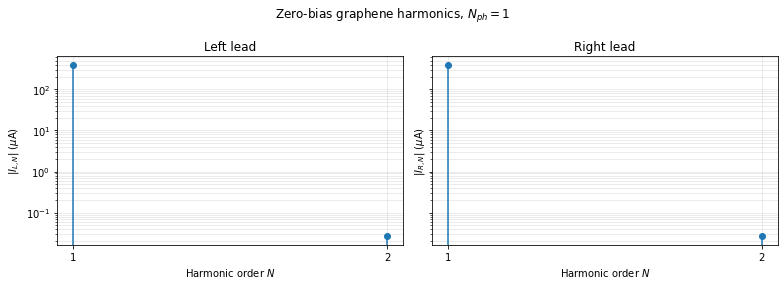

In [61]:
# ============================================================
# Cell D6-R&L: Zero-bias harmonic spectrum
#              (left panel: |I_L,N|, right panel: |I_R,N|)
# ============================================================

harmonic_orders = np.array(
    N_values_test,
    dtype=int
)

harmonic_magnitudes = np.array(
    [
        zero_bias_results[N]["magnitude"]
        for N in harmonic_orders
    ]
)

harmonic_magnitudes_left = np.array(
    [
        left_zero_bias_results[N]["magnitude"]
        for N in harmonic_orders
    ]
)

fig, (ax_left, ax_right) = plt.subplots(
    1, 2,
    figsize=(11, 4),
    sharey=True
)

ax_left.stem(
    harmonic_orders,
    harmonic_magnitudes_left,
    basefmt=" "
)
ax_left.set_yscale("log")
ax_left.set_xlabel(r"Harmonic order $N$")
ax_left.set_ylabel(r"$|I_{L,N}|$ ($\mu$A)")
ax_left.set_title("Left lead")
ax_left.set_xticks(harmonic_orders)
ax_left.grid(alpha=0.3, which="both")

ax_right.stem(
    harmonic_orders,
    harmonic_magnitudes,
    basefmt=" "
)
ax_right.set_yscale("log")
ax_right.set_xlabel(r"Harmonic order $N$")
ax_right.set_ylabel(r"$|I_{R,N}|$ ($\mu$A)")
ax_right.set_title("Right lead")
ax_right.set_xticks(harmonic_orders)
ax_right.grid(alpha=0.3, which="both")

fig.suptitle(
    rf"Zero-bias graphene harmonics, "
    rf"$N_{{ph}}={Nph}$"
)

plt.tight_layout()
plt.show()

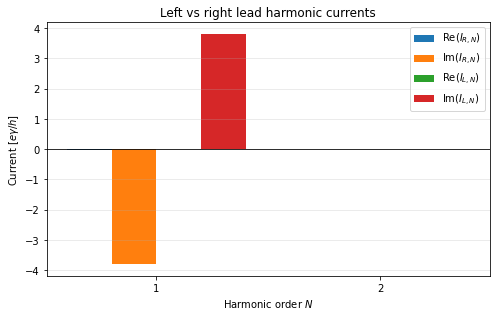

In [ ]:
# ============================================================
# Cell D6S1: Compare I_R,N and I_L,N vs harmonic order
# ============================================================

N_arr = np.array(N_values_test, dtype=int)

IL_arr = np.array(
    [left_zero_bias_results[N]["natural"] for N in N_values_test]
)
IR_arr = np.array(
    [zero_bias_results[N]["natural"] for N in N_values_test]
)

width = 0.2

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(N_arr - 1.5*width, IR_arr.real, width, label=r"Re$(I_{R,N})$")
ax.bar(N_arr - 0.5*width, IR_arr.imag, width, label=r"Im$(I_{R,N})$")
ax.bar(N_arr + 0.5*width, IL_arr.real, width, label=r"Re$(I_{L,N})$")
ax.bar(N_arr + 1.5*width, IL_arr.imag, width, label=r"Im$(I_{L,N})$")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel(r"Harmonic order $N$")
ax.set_ylabel(r"Current [$e\gamma/h$]")
ax.set_title("Left vs right lead harmonic currents")
ax.set_xticks(N_arr)
ax.grid(alpha=0.3, axis="y")
ax.legend()

plt.tight_layout()
plt.show()

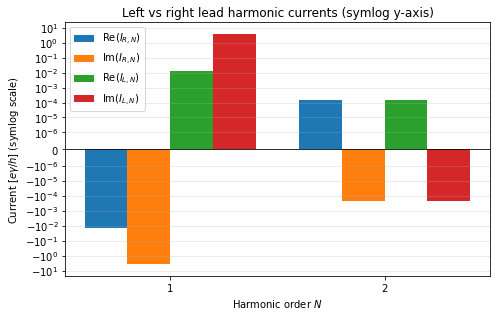

In [ ]:
# ============================================================
# Cell D6S1a: Compare I_R,N and I_L,N vs harmonic order
#             (Option A: symmetric log y-axis)
# ============================================================

N_arr = np.array(N_values_test, dtype=int)

IL_arr = np.array(
    [left_zero_bias_results[N]["natural"] for N in N_values_test]
)
IR_arr = np.array(
    [zero_bias_results[N]["natural"] for N in N_values_test]
)

width = 0.2

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(N_arr - 1.5*width, IR_arr.real, width, label=r"Re$(I_{R,N})$")
ax.bar(N_arr - 0.5*width, IR_arr.imag, width, label=r"Im$(I_{R,N})$")
ax.bar(N_arr + 0.5*width, IL_arr.real, width, label=r"Re$(I_{L,N})$")
ax.bar(N_arr + 1.5*width, IL_arr.imag, width, label=r"Im$(I_{L,N})$")

# Symmetric log scale: linear near zero (within linthresh),
# log-scaled beyond it. Lets widely different harmonic
# magnitudes (e.g. N=1 ~ 4, N=2 ~ 1e-4) share one axis.
ax.set_yscale("symlog", linthresh=1e-6)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel(r"Harmonic order $N$")
ax.set_ylabel(r"Current [$e\gamma/h$] (symlog scale)")
ax.set_title("Left vs right lead harmonic currents (symlog y-axis)")
ax.set_xticks(N_arr)
ax.grid(alpha=0.3, axis="y", which="both")
ax.legend()

plt.tight_layout()
plt.show()

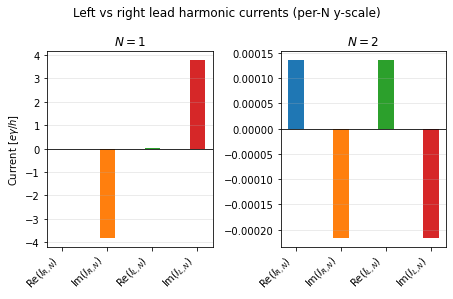

In [ ]:
# ============================================================
# Cell D6S1b: Compare I_R,N and I_L,N vs harmonic order
#             (Option B: one subplot per harmonic order N,
#              each with its own y-scale)
# ============================================================

N_arr = np.array(N_values_test, dtype=int)

IL_arr = np.array(
    [left_zero_bias_results[N]["natural"] for N in N_values_test]
)
IR_arr = np.array(
    [zero_bias_results[N]["natural"] for N in N_values_test]
)

n_panels = len(N_arr)

fig, axes = plt.subplots(
    1, n_panels,
    figsize=(3.2 * n_panels, 4.2),
    squeeze=False
)
axes = axes[0]

width = 0.35
labels = [r"Re$(I_{R,N})$", r"Im$(I_{R,N})$", r"Re$(I_{L,N})$", r"Im$(I_{L,N})$"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for ax, N, IR, IL in zip(axes, N_arr, IR_arr, IL_arr):

    values = [IR.real, IR.imag, IL.real, IL.imag]
    x_positions = np.arange(4)

    ax.bar(x_positions, values, width, color=colors)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(rf"$N = {N}$")
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel(r"Current [$e\gamma/h$]")

fig.suptitle("Left vs right lead harmonic currents (per-N y-scale)")
plt.tight_layout()
plt.show()

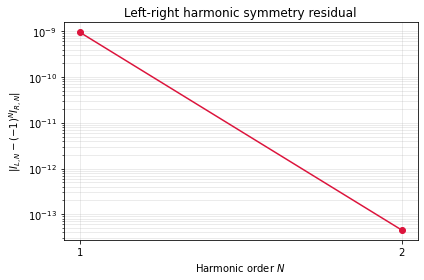

In [45]:
# ============================================================
# Cell D6S2: Left-right symmetry residual vs harmonic order
# ============================================================

N_arr = np.array(N_values_test, dtype=int)

residuals = np.array(
    [
        left_zero_bias_results[N]["natural"]
        - ((-1)**N) * zero_bias_results[N]["natural"]
        for N in N_values_test
    ]
)

residual_magnitudes = np.abs(residuals)

plt.figure(figsize=(6, 4))

plt.semilogy(
    N_arr,
    residual_magnitudes,
    "o-",
    color="crimson"
)

plt.xlabel(r"Harmonic order $N$")
plt.ylabel(r"$|I_{L,N} - (-1)^N I_{R,N}|$")
plt.title("Left-right harmonic symmetry residual")
plt.xticks(N_arr)
plt.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# Cell D7: Convergence of one graphene harmonic I_R,N versus Nph
# ============================================================

N_target = 3
Nph_values = np.arange(1, 6)   # Start with 1, 2, 3

# Use the same physical parameters for every truncation
z_test = z
omega_test = omega
EF_test = 0.0

# Use a moderate common energy grid first.
# Do not use NE=1000 while testing several Nph values.
NE_test = 20

I_values = []

for Nph_test in Nph_values:

    # The retained sectors are m = -Nph, ..., +Nph.
    # Therefore, the largest representable harmonic is 2*Nph.
    if N_target > 2 * Nph_test:

        I_values.append(np.nan + 1j * np.nan)

        print(
            f"Nph={Nph_test}: "
            f"N={N_target} cannot be represented."
        )

        continue

    print("\n" + "=" * 60)
    print(
        f"Calculating graphene harmonic "
        f"N={N_target}, Nph={Nph_test}"
    )
    print("=" * 60)

    # --------------------------------------------------------
    # 1. Rebuild the Fourier components for this Nph
    # --------------------------------------------------------

    H_fourier_test = device_fourier_components(
        Nx=Nx,
        Ny=Ny,
        gamma=gamma,
        z=z_test,
        Mmax=2 * Nph_test,
        N_phase=N_phase
    )

    # --------------------------------------------------------
    # 2. Rebuild the Floquet Hamiltonian and photon matrix
    # --------------------------------------------------------

    HF_test, OmegaF_test = assemble_floquet_matrices(
        H_fourier=H_fourier_test,
        Nph=Nph_test,
        omega=omega_test
    )

    print(
        "Floquet matrix dimension =",
        HF_test.shape[0]
    )

    # --------------------------------------------------------
    # 3. Calculate only the selected harmonic N_target
    # --------------------------------------------------------

    result_test, _, _ = graphene_zero_bias_harmonics(
        N_values=[N_target],
        HF=HF_test,
        OmegaF=OmegaF_test,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph_test,
        omega=omega_test,
        EF=EF_test,
        eta=eta_floquet,
        E_min=-3.0,
        E_max=0.0,
        NE=NE_test,
        temperature_mode="zero",
        gamma_eV=gamma_eV,
        spin_degeneracy=spin_degeneracy,
        print_progress=True
    )

    IN = result_test[N_target]["microamp"]

    I_values.append(IN)

    print(
        f"Nph={Nph_test}: "
        f"I_R,{N_target} = "
        f"{IN.real:+.6e} {IN.imag:+.6e}j microampere"
    )

    print(
        f"|I_R,{N_target}| = "
        f"{abs(IN):.6e} microampere"
    )

    # Free the large Floquet matrices before the next Nph
    del H_fourier_test
    del HF_test
    del OmegaF_test


I_values = np.asarray(
    I_values,
    dtype=complex
)

I_abs = np.abs(I_values)

Nph=1: N=3 cannot be represented.

Calculating graphene harmonic N=3, Nph=2
Floquet matrix dimension = 8700
Energy   1/20: E = -3.000000 gamma
Energy   2/20: E = -2.842105 gamma
Energy   3/20: E = -2.684211 gamma
Energy   4/20: E = -2.526316 gamma
Energy   5/20: E = -2.368421 gamma
Energy   6/20: E = -2.210526 gamma
Energy   7/20: E = -2.052632 gamma
Energy   8/20: E = -1.894737 gamma
Energy   9/20: E = -1.736842 gamma
Energy  10/20: E = -1.578947 gamma
Energy  11/20: E = -1.421053 gamma
Energy  12/20: E = -1.263158 gamma
Energy  13/20: E = -1.105263 gamma
Energy  14/20: E = -0.947368 gamma
Energy  15/20: E = -0.789474 gamma
Energy  16/20: E = -0.631579 gamma
Energy  17/20: E = -0.473684 gamma
Energy  18/20: E = -0.315789 gamma
Energy  19/20: E = -0.157895 gamma
Energy  20/20: E = +0.000000 gamma
Nph=2: I_R,3 = -2.094314e-03 +8.665924e-03j microampere
|I_R,3| = 8.915402e-03 microampere

Calculating graphene harmonic N=3, Nph=3
Floquet matrix dimension = 12180
Energy   1/20: E = -3.0000

In [49]:
# ============================================================
# Cell D7R: Relative change between consecutive Nph values
# ============================================================

relative_change = np.full(
    len(Nph_values),
    np.nan
)

for i in range(1, len(Nph_values)):

    # Skip missing/unrepresentable values
    if (
        np.isnan(I_values[i].real)
        or np.isnan(I_values[i - 1].real)
    ):
        continue

    denominator = abs(I_values[i - 1])

    if denominator > 1e-30:

        relative_change[i] = (
            abs(I_values[i] - I_values[i - 1])
            / denominator
        )


print("\n" + "=" * 65)
print(
    f"Floquet-truncation convergence for harmonic N={N_target}"
)
print("=" * 65)

for Nph_test, IN, rel in zip(
    Nph_values,
    I_values,
    relative_change
):

    if np.isnan(IN.real):

        print(
            f"Nph={Nph_test}: "
            f"N={N_target} cannot be represented."
        )

        continue

    convergence_text = (
        "not available"
        if np.isnan(rel)
        else f"{rel:.3e}"
    )

    print(
        f"Nph={Nph_test}: "
        f"I_R,{N_target} = "
        f"{IN.real:+.6e} {IN.imag:+.6e}j microampere, "
        f"|I| = {abs(IN):.6e} microampere, "
        f"relative change = {convergence_text}"
    )


Floquet-truncation convergence for harmonic N=3
Nph=1: N=3 cannot be represented.
Nph=2: I_R,3 = -2.094314e-03 +8.665924e-03j microampere, |I| = 8.915402e-03 microampere, relative change = not available
Nph=3: I_R,3 = -3.390700e-03 +8.383443e-03j microampere, |I| = 9.043172e-03 microampere, relative change = 1.488e-01
Nph=4: I_R,3 = -2.704048e-03 +8.620009e-03j microampere, |I| = 9.034181e-03 microampere, relative change = 8.031e-02
Nph=5: I_R,3 = -2.702871e-03 +8.618351e-03j microampere, |I| = 9.032247e-03 microampere, relative change = 2.251e-04


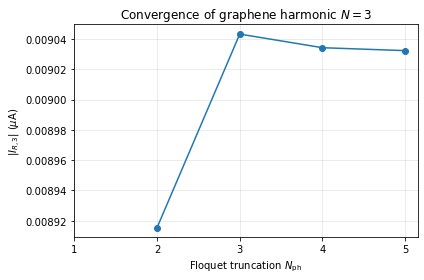

In [50]:
# ============================================================
# Cell D7p: Plot |I_R,N| versus Nph
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    Nph_values,
    I_abs,
    marker="o"
)

plt.xlabel(r"Floquet truncation $N_{\rm ph}$")
plt.ylabel(
    rf"$|I_{{R,{N_target}}}|$ ($\mu$A)"
)

plt.title(
    rf"Convergence of graphene harmonic $N={N_target}$"
)

plt.xticks(Nph_values)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Part F:
Final tests:

In [51]:
# ============================================================
# FINAL HARMONIC SPECTRUM, For higher Nph
# Cell F1: Build the final Floquet graphene system
# ============================================================

# Floquet truncation selected from the convergence test
Nph_final = 4

# Harmonics that can be represented with this truncation
N_values_final = np.arange(
    1,
    2 * Nph_final + 1
)

# Use the same physical driving parameters as before
z_final = z
omega_final = omega

# Number of phase points used to calculate H_m
N_phase_final = N_phase

print("Final Floquet truncation Nph =", Nph_final)
print("Representable harmonics      =", N_values_final)

# ------------------------------------------------------------
# Calculate Fourier components H_m for the chosen Nph
# ------------------------------------------------------------

H_fourier_final = device_fourier_components(
    Nx=Nx,
    Ny=Ny,
    gamma=gamma,
    z=z_final,
    Mmax=2 * Nph_final,
    N_phase=N_phase_final
)

# ------------------------------------------------------------
# Assemble the final Floquet Hamiltonian and photon matrix
# ------------------------------------------------------------

HF_final, OmegaF_final = assemble_floquet_matrices(
    H_fourier=H_fourier_final,
    Nph=Nph_final,
    omega=omega_final
)

print("Final Floquet matrix dimension =", HF_final.shape[0])

print(
    "HF Hermiticity error =",
    np.linalg.norm(
        HF_final - HF_final.conj().T
    )
)

Final Floquet truncation Nph = 4
Representable harmonics      = [1 2 3 4 5 6 7 8]
Final Floquet matrix dimension = 15660
HF Hermiticity error = 0.0


In [52]:
# ============================================================
# Cell F2R: Calculate the final zero-bias harmonic coefficients
#right lead
# ============================================================

# Start with a moderate common energy grid.
# Increase later after checking runtime and convergence.
NE_final = 80

final_results, E_grid_final, integrands_final = (
    graphene_zero_bias_harmonics(
        N_values=N_values_final,
        HF=HF_final,
        OmegaF=OmegaF_final,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph_final,
        omega=omega_final,
        EF=0.0,
        eta=eta_floquet,
        E_min=-3.0,
        E_max=0.0,
        NE=NE_final,
        temperature_mode="zero",
        gamma_eV=gamma_eV,
        spin_degeneracy=spin_degeneracy,
        print_progress=True
    )
)

Energy   1/80: E = -3.000000 gamma
Energy   2/80: E = -2.962025 gamma
Energy   3/80: E = -2.924051 gamma
Energy   4/80: E = -2.886076 gamma
Energy   5/80: E = -2.848101 gamma
Energy   6/80: E = -2.810127 gamma
Energy   7/80: E = -2.772152 gamma
Energy   8/80: E = -2.734177 gamma
Energy   9/80: E = -2.696203 gamma
Energy  10/80: E = -2.658228 gamma
Energy  11/80: E = -2.620253 gamma
Energy  12/80: E = -2.582278 gamma
Energy  13/80: E = -2.544304 gamma
Energy  14/80: E = -2.506329 gamma
Energy  15/80: E = -2.468354 gamma
Energy  16/80: E = -2.430380 gamma
Energy  17/80: E = -2.392405 gamma
Energy  18/80: E = -2.354430 gamma
Energy  19/80: E = -2.316456 gamma
Energy  20/80: E = -2.278481 gamma
Energy  21/80: E = -2.240506 gamma
Energy  22/80: E = -2.202532 gamma
Energy  23/80: E = -2.164557 gamma
Energy  24/80: E = -2.126582 gamma
Energy  25/80: E = -2.088608 gamma
Energy  26/80: E = -2.050633 gamma
Energy  27/80: E = -2.012658 gamma
Energy  28/80: E = -1.974684 gamma
Energy  29/80: E = -

In [53]:
# ============================================================
# Cell F2L: Calculate the final zero-bias harmonic coefficients
#           (LEFT lead)
# ============================================================

final_results_left, E_grid_final_left, integrands_final_left = (
    graphene_zero_bias_harmonics_left(
        N_values=N_values_final,
        HF=HF_final,
        OmegaF=OmegaF_final,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph_final,
        omega=omega_final,
        EF=0.0,
        eta=eta_floquet,
        E_min=-3.0,
        E_max=0.0,
        NE=NE_final,
        temperature_mode="zero",
        gamma_eV=gamma_eV,
        spin_degeneracy=spin_degeneracy,
        print_progress=True
    )
)

LEFT current: Energy   1/80: E = -3.000000 gamma
LEFT current: Energy   2/80: E = -2.962025 gamma
LEFT current: Energy   3/80: E = -2.924051 gamma
LEFT current: Energy   4/80: E = -2.886076 gamma
LEFT current: Energy   5/80: E = -2.848101 gamma
LEFT current: Energy   6/80: E = -2.810127 gamma
LEFT current: Energy   7/80: E = -2.772152 gamma
LEFT current: Energy   8/80: E = -2.734177 gamma
LEFT current: Energy   9/80: E = -2.696203 gamma
LEFT current: Energy  10/80: E = -2.658228 gamma
LEFT current: Energy  11/80: E = -2.620253 gamma
LEFT current: Energy  12/80: E = -2.582278 gamma
LEFT current: Energy  13/80: E = -2.544304 gamma
LEFT current: Energy  14/80: E = -2.506329 gamma
LEFT current: Energy  15/80: E = -2.468354 gamma
LEFT current: Energy  16/80: E = -2.430380 gamma
LEFT current: Energy  17/80: E = -2.392405 gamma
LEFT current: Energy  18/80: E = -2.354430 gamma
LEFT current: Energy  19/80: E = -2.316456 gamma
LEFT current: Energy  20/80: E = -2.278481 gamma
LEFT current: Energy

### DC (N=0) charge current: computation and cross-checks

The AC harmonic formula used throughout Part D/F ($`S_m^†S_{m+N}`$, valid for
$N\ge1$) cannot simply be evaluated at $N=0$ — the incoming-electron term that
drops out automatically for every $N\ne0$ must be kept explicitly at $N=0$
(see the derivation notes, Eqs. 36–38). The five cells below compute the DC
current two independent ways and verify they agree, motivated by Branislav's
question of whether a symmetric two-terminal junction gives $I_{DC}=0$
(Foa Torres et al., PRL 113, 266801 (2014)).

**F2-DC1 / F2-DC2 — trustworthy result.**
Uses the standard Landauer form, transmission-only, opposite sign between
leads by construction:
$$I_{R,0} = \frac{e}{h}\int dE\,\big[T_{RL}(E)f_L(E) - T_{LR}(E)f_R(E)\big], \qquad I_{L,0} = -I_{R,0}$$
Same-lead reflection terms never enter — unlike the AC harmonics, DC
transport only cares about net transmission. This never depends on any
completeness/unitarity cancellation, so it's numerically robust. Result:
$I_{R,0}\approx6.6\times10^{-9}$ μA — consistent with zero, as expected for
this symmetric junction.

**F2-DC1b / F2-DC2b — cross-check against the original notes' formula.**
Implements the DC current exactly as first derived (Eqs. 36–41): keeps the
same-lead reflection terms and subtracts the incoming-electron term
$f_p(E)\,\mathrm{Tr}[\mathbb{1}]$ explicitly, with $\mathrm{Tr}[\mathbb{1}]=n_{orb}=58$
(the full local-orbital identity — not just the open-channel count; see
diagnostic below). Gives $I_{R,0}\approx-1.19$ μA — much larger than F2-DC1's
result, because this formula requires the truncated Floquet sideband sum to
satisfy unitarity almost exactly, and a small truncation gap becomes visible
once inflated by cancellation between two much larger ($O(1\text{–}60)$)
quantities.

**F2-DC-diag — where the residual comes from.**
At a sample energy, the truncated sum $\sum_m[\mathrm{Tr}(S_{LL,m}^\dagger S_{LL,m}) + \mathrm{Tr}(S_{RL,m}^\dagger S_{RL,m})]$
equals $57.999405$ against the exact target $n_{orb}=58$ — a $6\times10^{-4}$
absolute gap from finite $N_{ph}=4$ truncation. Small per energy point, but
enough to integrate up to the $\sim1$ μA scale seen in F2-DC1b.

**F2-DC-diag2 — why F2-DC1b gives the *same* sign for both leads.**
Directly verifies $T_{RL}=T_{LR}$ and $R_{LL}=R_{RR}$ to $\sim10^{-14}$ — an
exact reciprocity of this driven device, at a precision far tighter than the
$10^{-4}$ unitarity gap above. This reciprocity forces F2-DC1b's two leads to
give near-identical (same-sign) values rather than the opposite-sign result
required by charge conservation — explaining the earlier confusing output
without pointing to any actual bug in the code.

**Conclusion.** Both formulas encode the same physics; F2-DC1 accesses it
robustly (via $T_{RL}=T_{LR}$ directly), while F2-DC1b is textbook-correct
but numerically fragile under Floquet truncation. $I_{DC}\approx0$ is
therefore a well-supported result for this symmetric junction, consistent
with the Foa Torres reference Branislav circulated.

In [64]:
# ============================================================
# Cell F2-DC1: DC (N=0) charge-current integrand at one energy
#              (both leads, computed together)
#
# CORRECTED: the physical DC (time-averaged) current uses ONLY
# cross-lead transmission terms, with opposite sign between the
# two leads' contributions (standard Landauer form, matching
# Eq. (2) of Foa Torres et al., PRL 113, 266801 (2014)):
#
#     I_R = (e/h) Int [ T_RL(E) fL(E) - T_LR(E) fR(E) ] dE
#
# Unlike the AC (N>=1) harmonics, same-lead reflection terms
# (S_RR, S_LL) do NOT enter the net DC current -- reflected
# electrons that leave and return to the same lead transfer no
# net charge in steady state, even though they do contribute to
# the AC harmonics (D3's formula, N>=1) via inelastic
# (photon-assisted) reflection.
#
# F_{R,0}(E) = sum_m [ Tr(S_RL,m^dagger S_RL,m) fL(E)
#                      - Tr(S_LR,m^dagger S_LR,m) fR(E) ]
#
# F_{L,0}(E) = -F_{R,0}(E)   exactly, by construction --
#              this guarantees charge conservation I_L,0=-I_R,0
#              algebraically, not just numerically.
# ============================================================

def graphene_dc_integrand_at_energy(
    E, HF, OmegaF, H00, H01, Nx, Nph, omega,
    muL, muR, eta=1e-6, temperature_mode="zero", kBT=0.01
):
    fL_E = reservoir_occupation(E=E, mu=muL, temperature_mode=temperature_mode, kBT=kBT)
    fR_E = reservoir_occupation(E=E, mu=muR, temperature_mode=temperature_mode, kBT=kBT)

    if fL_E == 0.0 and fR_E == 0.0:
        return 0.0 + 0.0j, 0.0 + 0.0j

    G_by_m, _, _ = graphene_contact_green_blocks(
        E=E, HF=HF, OmegaF=OmegaF, H00=H00, H01=H01,
        Nx=Nx, Nph=Nph, omega=omega, eta=eta
    )
    S_by_m, _ = build_graphene_scattering_matrices(
        G_by_m=G_by_m, E=E, H00=H00, H01=H01, omega=omega, eta=eta
    )

    T_RL_total = 0.0 + 0.0j
    T_LR_total = 0.0 + 0.0j

    for m, S in S_by_m.items():
        T_RL_total += np.trace(S["RL"].conj().T @ S["RL"])
        T_LR_total += np.trace(S["LR"].conj().T @ S["LR"])

    F_R0 = fL_E * T_RL_total - fR_E * T_LR_total
    F_L0 = -F_R0

    return F_R0, F_L0

In [65]:
# ============================================================
# Cell F2-DC2: Energy integration for the final DC (N=0) current
#              (both leads), at the final Nph_final truncation
# ============================================================

E_grid_dc = np.linspace(
    -3.0,
    0.0,
    NE_final
)

integrand_R0 = np.zeros(NE_final, dtype=complex)
integrand_L0 = np.zeros(NE_final, dtype=complex)

for iE, E in enumerate(E_grid_dc):

    F_R0, F_L0 = graphene_dc_integrand_at_energy(
        E=E,
        HF=HF_final,
        OmegaF=OmegaF_final,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph_final,
        omega=omega_final,
        muL=0.0,
        muR=0.0,
        eta=eta_floquet,
        temperature_mode="zero"
    )

    integrand_R0[iE] = F_R0
    integrand_L0[iE] = F_L0

    print(
        f"DC energy {iE + 1:3d}/{NE_final}: "
        f"E = {E:+.6f} gamma"
    )

I_R0_natural = spin_degeneracy * np.trapz(integrand_R0, E_grid_dc)
I_L0_natural = spin_degeneracy * np.trapz(integrand_L0, E_grid_dc)

I_R0_microamp = EV_OVER_H_TO_UA * gamma_eV * I_R0_natural
I_L0_microamp = EV_OVER_H_TO_UA * gamma_eV * I_L0_natural

# Fold the DC (N=0) result into the existing final_results
# dictionaries, alongside the AC harmonics already stored there.
final_results[0] = {
    "natural": I_R0_natural,
    "microamp": I_R0_microamp,
    "magnitude": abs(I_R0_microamp)
}

final_results_left[0] = {
    "natural": I_L0_natural,
    "microamp": I_L0_microamp,
    "magnitude": abs(I_L0_microamp)
}

print("\nI_R,0 (DC) =", I_R0_microamp, "microampere")
print("I_L,0 (DC) =", I_L0_microamp, "microampere")

DC energy   1/80: E = -3.000000 gamma
DC energy   2/80: E = -2.962025 gamma
DC energy   3/80: E = -2.924051 gamma
DC energy   4/80: E = -2.886076 gamma
DC energy   5/80: E = -2.848101 gamma
DC energy   6/80: E = -2.810127 gamma
DC energy   7/80: E = -2.772152 gamma
DC energy   8/80: E = -2.734177 gamma
DC energy   9/80: E = -2.696203 gamma
DC energy  10/80: E = -2.658228 gamma
DC energy  11/80: E = -2.620253 gamma
DC energy  12/80: E = -2.582278 gamma
DC energy  13/80: E = -2.544304 gamma
DC energy  14/80: E = -2.506329 gamma
DC energy  15/80: E = -2.468354 gamma
DC energy  16/80: E = -2.430380 gamma
DC energy  17/80: E = -2.392405 gamma
DC energy  18/80: E = -2.354430 gamma
DC energy  19/80: E = -2.316456 gamma
DC energy  20/80: E = -2.278481 gamma
DC energy  21/80: E = -2.240506 gamma
DC energy  22/80: E = -2.202532 gamma
DC energy  23/80: E = -2.164557 gamma
DC energy  24/80: E = -2.126582 gamma
DC energy  25/80: E = -2.088608 gamma
DC energy  26/80: E = -2.050633 gamma
DC energy  2

In [71]:
# ============================================================
# Cell F2-DC1b: DC (N=0) integrand via EXPLICIT incoming-term
#               subtraction (matches the notes' Eqs. 36-41)
#
# REVERTED: Tr[1] is the FULL local-orbital identity (n_orb=58),
# not just the open-channel count. Diagnostic check confirmed
# the truncated unitarity sum (sum over retained m) equals
# n_orb=58 to ~1e-5 relative precision -- in closed-channel
# directions the Fisher-Lee S-matrix reduces to S=1 exactly
# (since sqrt(Gamma)->0 kills the scattering term there), so
# those directions still contribute exactly 1 each to the trace.
# The earlier open-channel-count version was a regression.
#
# I_R,0^in(E) = fR(E) * n_orb
# I_L,0^in(E) = fL(E) * n_orb
#
# The remaining (much smaller) O(1) microampere-scale residual
# against F2-DC1 comes from the finite-Nph truncation leakage
# itself (~6e-4 absolute per energy point here), and should
# shrink as Nph_final is increased.
# ============================================================

def graphene_dc_integrand_explicit_at_energy(
    E, HF, OmegaF, H00, H01, Nx, Nph, omega,
    muL, muR, eta=1e-6, temperature_mode="zero", kBT=0.01
):
    fL_E = reservoir_occupation(E=E, mu=muL, temperature_mode=temperature_mode, kBT=kBT)
    fR_E = reservoir_occupation(E=E, mu=muR, temperature_mode=temperature_mode, kBT=kBT)

    if fL_E == 0.0 and fR_E == 0.0:
        return 0.0 + 0.0j, 0.0 + 0.0j

    G_by_m, _, _ = graphene_contact_green_blocks(
        E=E, HF=HF, OmegaF=OmegaF, H00=H00, H01=H01,
        Nx=Nx, Nph=Nph, omega=omega, eta=eta
    )
    S_by_m, _ = build_graphene_scattering_matrices(
        G_by_m=G_by_m, E=E, H00=H00, H01=H01, omega=omega, eta=eta
    )

    n_orb = H00.shape[0]
    trace_identity = float(n_orb)

    out_R = 0.0 + 0.0j
    out_L = 0.0 + 0.0j

    for m, S in S_by_m.items():
        out_R += fL_E * np.trace(S["RL"].conj().T @ S["RL"]) + fR_E * np.trace(S["RR"].conj().T @ S["RR"])
        out_L += fR_E * np.trace(S["LR"].conj().T @ S["LR"]) + fL_E * np.trace(S["LL"].conj().T @ S["LL"])

    in_R = fR_E * trace_identity
    in_L = fL_E * trace_identity

    F_R0 = out_R - in_R
    F_L0 = out_L - in_L

    return F_R0, F_L0

In [73]:
# ============================================================
# Cell F2-DC2b: Energy integration for the explicit-subtraction
#               DC (N=0) current, and comparison to F2-DC2
# ============================================================

integrand_R0_explicit = np.zeros(NE_final, dtype=complex)
integrand_L0_explicit = np.zeros(NE_final, dtype=complex)

for iE, E in enumerate(E_grid_dc):

    F_R0, F_L0 = graphene_dc_integrand_explicit_at_energy(
        E=E, HF=HF_final, OmegaF=OmegaF_final, H00=H00, H01=H01,
        Nx=Nx, Nph=Nph_final, omega=omega_final,
        muL=0.0, muR=0.0, eta=eta_floquet, temperature_mode="zero"
    )

    integrand_R0_explicit[iE] = F_R0
    integrand_L0_explicit[iE] = F_L0

    # Print only occasionally so the final comparison below is not
    # pushed into a truncated middle section of a long cell output.
    if (iE + 1) % 10 == 0 or (iE + 1) == NE_final:
        print(f"DC (explicit) energy {iE + 1:3d}/{NE_final}: E = {E:+.6f} gamma")

I_R0_natural_explicit = spin_degeneracy * np.trapz(integrand_R0_explicit, E_grid_dc)
I_L0_natural_explicit = spin_degeneracy * np.trapz(integrand_L0_explicit, E_grid_dc)

I_R0_microamp_explicit = EV_OVER_H_TO_UA * gamma_eV * I_R0_natural_explicit
I_L0_microamp_explicit = EV_OVER_H_TO_UA * gamma_eV * I_L0_natural_explicit

print("\n" + "=" * 70)
print("N=0 (DC): comparison of the two formulas")
print("=" * 70)

print("\n--- I_R,0 (DC current into the RIGHT lead) ---")
print(f"  I_R,0  [unitarity-reduced, F2-DC1] = {I_R0_microamp:.6e} microampere")
print(f"  I_R,0  [explicit subtraction]      = {I_R0_microamp_explicit:.6e} microampere")

diff_R = abs(I_R0_microamp_explicit - I_R0_microamp)
scale_R = max(abs(I_R0_microamp), abs(I_R0_microamp_explicit), 1e-30)
print(f"  |I_R,0(explicit) - I_R,0(F2-DC1)| = {diff_R:.6e} microampere")
print(f"  relative difference = {diff_R/scale_R:.6e}")

print("\n--- I_L,0 (DC current into the LEFT lead) ---")
print(f"  I_L,0  [unitarity-reduced, F2-DC1] = {I_L0_microamp:.6e} microampere")
print(f"  I_L,0  [explicit subtraction]      = {I_L0_microamp_explicit:.6e} microampere")

diff_L = abs(I_L0_microamp_explicit - I_L0_microamp)
scale_L = max(abs(I_L0_microamp), abs(I_L0_microamp_explicit), 1e-30)
print(f"  |I_L,0(explicit) - I_L,0(F2-DC1)| = {diff_L:.6e} microampere")
print(f"  relative difference = {diff_L/scale_L:.6e}")

DC (explicit) energy  10/80: E = -2.658228 gamma
DC (explicit) energy  20/80: E = -2.278481 gamma
DC (explicit) energy  30/80: E = -1.898734 gamma
DC (explicit) energy  40/80: E = -1.518987 gamma
DC (explicit) energy  50/80: E = -1.139241 gamma
DC (explicit) energy  60/80: E = -0.759494 gamma
DC (explicit) energy  70/80: E = -0.379747 gamma
DC (explicit) energy  80/80: E = +0.000000 gamma

N=0 (DC): comparison of the two formulas

--- I_R,0 (DC current into the RIGHT lead) ---
  I_R,0  [unitarity-reduced, F2-DC1] = 6.589833e-09+0.000000e+00j microampere
  I_R,0  [explicit subtraction]      = -1.194371e+00+0.000000e+00j microampere
  |I_R,0(explicit) - I_R,0(F2-DC1)| = 1.194371e+00 microampere
  relative difference = 1.000000e+00

--- I_L,0 (DC current into the LEFT lead) ---
  I_L,0  [unitarity-reduced, F2-DC1] = -6.589833e-09+0.000000e+00j microampere
  I_L,0  [explicit subtraction]      = -1.194371e+00+0.000000e+00j microampere
  |I_L,0(explicit) - I_L,0(F2-DC1)| = 1.194371e+00 micro

In [70]:
# ============================================================
# Cell F2-DC-diag: Check truncated-m unitarity sum vs N_open
#                  at one sample energy, to see the gap left
#                  by the finite Nph truncation.
# ============================================================

E_test = -1.5

G_by_m_test, _, _ = graphene_contact_green_blocks(
    E=E_test, HF=HF_final, OmegaF=OmegaF_final, H00=H00, H01=H01,
    Nx=Nx, Nph=Nph_final, omega=omega_final, eta=eta_floquet
)

S_by_m_test, incoming_test = build_graphene_scattering_matrices(
    G_by_m=G_by_m_test, E=E_test, H00=H00, H01=H01, omega=omega_final, eta=eta_floquet
)

A_sum = sum(np.trace(S["LL"].conj().T @ S["LL"]) for S in S_by_m_test.values())
C_sum = sum(np.trace(S["RL"].conj().T @ S["RL"]) for S in S_by_m_test.values())

n_open_L_test = count_open_channels(incoming_test["GammaL"])

print(f"E_test = {E_test} gamma, Nph_final = {Nph_final}")
print(f"Retained Floquet sectors m = {sorted(S_by_m_test.keys())}")
print()
print(f"Truncated unitarity sum, A + C = {(A_sum + C_sum).real:.6f}")
print(f"N_open,L(E_test) (eigenvalue count) = {n_open_L_test:.6f}")
print(f"Gap = {(A_sum + C_sum).real - n_open_L_test:.6f}")
print(f"Relative gap = {abs((A_sum + C_sum).real - n_open_L_test) / max(n_open_L_test, 1e-12):.6e}")

E_test = -1.5 gamma, Nph_final = 4
Retained Floquet sectors m = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

Truncated unitarity sum, A + C = 57.999405
N_open,L(E_test) (eigenvalue count) = 25.000000
Gap = 32.999405
Relative gap = 1.319976e+00


In [75]:
# ============================================================
# Cell F2-DC-diag2: Test whether T_RL~T_LR and R_LL~R_RR
#                   individually (reciprocity-like symmetry),
#                   independent of whether full unitarity holds
# ============================================================

T_RL_total = sum(np.trace(S["RL"].conj().T @ S["RL"]) for S in S_by_m_test.values())
T_LR_total = sum(np.trace(S["LR"].conj().T @ S["LR"]) for S in S_by_m_test.values())
R_LL_total = sum(np.trace(S["LL"].conj().T @ S["LL"]) for S in S_by_m_test.values())
R_RR_total = sum(np.trace(S["RR"].conj().T @ S["RR"]) for S in S_by_m_test.values())

print(f"T_RL_total = {T_RL_total.real:.8f}")
print(f"T_LR_total = {T_LR_total.real:.8f}")
print(f"T_RL - T_LR = {(T_RL_total - T_LR_total).real:.3e}")
print()
print(f"R_LL_total = {R_LL_total.real:.8f}")
print(f"R_RR_total = {R_RR_total.real:.8f}")
print(f"R_LL - R_RR = {(R_LL_total - R_RR_total).real:.3e}")
print()
print(f"Full unitarity check (R-incoming): T_LR + R_RR = {(T_LR_total + R_RR_total).real:.6f}")
print(f"Full unitarity check (L-incoming): T_RL + R_LL = {(T_RL_total + R_LL_total).real:.6f}")
print(f"n_orb = {H00.shape[0]}")

T_RL_total = 1.00002768
T_LR_total = 1.00002768
T_RL - T_LR = -2.554e-14

R_LL_total = 56.99937756
R_RR_total = 56.99937756
R_LL - R_RR = 2.842e-14

Full unitarity check (R-incoming): T_LR + R_RR = 57.999405
Full unitarity check (L-incoming): T_RL + R_LL = 57.999405
n_orb = 58


In [54]:
# ============================================================
# Cell F3: Print final harmonic-current coefficients
#          (both LEFT and RIGHT leads)
# ============================================================

print("\n" + "=" * 70)
print("Final zero-bias graphene harmonic spectrum")
print("=" * 70)

for N in N_values_final:

    IR_natural = final_results[N]["natural"]
    IR_microamp = final_results[N]["microamp"]
    IR_magnitude = final_results[N]["magnitude"]

    IL_natural = final_results_left[N]["natural"]
    IL_microamp = final_results_left[N]["microamp"]
    IL_magnitude = final_results_left[N]["magnitude"]

    print(f"\nN = {N:2d}")

    print(
        f"  I_R,N = {IR_natural.real:+.6e} "
        f"{IR_natural.imag:+.6e}j [e gamma / h]"
    )
    print(
        f"        = {IR_microamp.real:+.6e} "
        f"{IR_microamp.imag:+.6e}j microampere"
    )
    print(
        f"        |I_R,N| = {IR_magnitude:.6e} microampere"
    )

    print(
        f"  I_L,N = {IL_natural.real:+.6e} "
        f"{IL_natural.imag:+.6e}j [e gamma / h]"
    )
    print(
        f"        = {IL_microamp.real:+.6e} "
        f"{IL_microamp.imag:+.6e}j microampere"
    )
    print(
        f"        |I_L,N| = {IL_magnitude:.6e} microampere"
    )


Final zero-bias graphene harmonic spectrum

N =  1
  I_R,N = -1.149365e+00 -3.381219e+00j [e gamma / h]
        = -1.202213e+02 -3.536688e+02j microampere
        |I_R,N| = 3.735435e+02 microampere
  I_L,N = +1.149365e+00 +3.381219e+00j [e gamma / h]
        = +1.202213e+02 +3.536688e+02j microampere
        |I_L,N| = 3.735435e+02 microampere

N =  2
  I_R,N = -5.834778e-04 +9.813324e-04j [e gamma / h]
        = -6.103061e-02 +1.026454e-01j microampere
        |I_R,N| = 1.194187e-01 microampere
  I_L,N = -5.834778e-04 +9.813324e-04j [e gamma / h]
        = -6.103061e-02 +1.026454e-01j microampere
        |I_L,N| = 1.194187e-01 microampere

N =  3
  I_R,N = -2.498774e-05 +8.339038e-05j [e gamma / h]
        = -2.613668e-03 +8.722466e-03j microampere
        |I_R,N| = 9.105640e-03 microampere
  I_L,N = +2.498774e-05 -8.339038e-05j [e gamma / h]
        = +2.613668e-03 -8.722466e-03j microampere
        |I_L,N| = 9.105640e-03 microampere

N =  4
  I_R,N = +4.778450e-06 -1.020719e-06j [e 

In [56]:
# ============================================================
# Cell F3: Print final harmonic-current coefficients
#          (both LEFT and RIGHT leads; N labeled on every line)
# ============================================================

print("\n" + "=" * 70)
print("Final zero-bias graphene harmonic spectrum")
print("=" * 70)

for N in N_values_final:

    IR_natural = final_results[N]["natural"]
    IR_microamp = final_results[N]["microamp"]
    IR_magnitude = final_results[N]["magnitude"]

    IL_natural = final_results_left[N]["natural"]
    IL_microamp = final_results_left[N]["microamp"]
    IL_magnitude = final_results_left[N]["magnitude"]

    print(f"\nN = {N:2d}")

    print(
        f"  [N={N:2d}] I_R,N = {IR_natural.real:+.6e} "
        f"{IR_natural.imag:+.6e}j [e gamma / h]"
    )
    print(
        f"  [N={N:2d}]       = {IR_microamp.real:+.6e} "
        f"{IR_microamp.imag:+.6e}j microampere"
    )
    print(
        f"  [N={N:2d}]       |I_R,N| = {IR_magnitude:.6e} microampere"
    )

    print(
        f"  [N={N:2d}] I_L,N = {IL_natural.real:+.6e} "
        f"{IL_natural.imag:+.6e}j [e gamma / h]"
    )
    print(
        f"  [N={N:2d}]       = {IL_microamp.real:+.6e} "
        f"{IL_microamp.imag:+.6e}j microampere"
    )
    print(
        f"  [N={N:2d}]       |I_L,N| = {IL_magnitude:.6e} microampere"
    )


Final zero-bias graphene harmonic spectrum

N =  1
  [N= 1] I_R,N = -1.149365e+00 -3.381219e+00j [e gamma / h]
  [N= 1]       = -1.202213e+02 -3.536688e+02j microampere
  [N= 1]       |I_R,N| = 3.735435e+02 microampere
  [N= 1] I_L,N = +1.149365e+00 +3.381219e+00j [e gamma / h]
  [N= 1]       = +1.202213e+02 +3.536688e+02j microampere
  [N= 1]       |I_L,N| = 3.735435e+02 microampere

N =  2
  [N= 2] I_R,N = -5.834778e-04 +9.813324e-04j [e gamma / h]
  [N= 2]       = -6.103061e-02 +1.026454e-01j microampere
  [N= 2]       |I_R,N| = 1.194187e-01 microampere
  [N= 2] I_L,N = -5.834778e-04 +9.813324e-04j [e gamma / h]
  [N= 2]       = -6.103061e-02 +1.026454e-01j microampere
  [N= 2]       |I_L,N| = 1.194187e-01 microampere

N =  3
  [N= 3] I_R,N = -2.498774e-05 +8.339038e-05j [e gamma / h]
  [N= 3]       = -2.613668e-03 +8.722466e-03j microampere
  [N= 3]       |I_R,N| = 9.105640e-03 microampere
  [N= 3] I_L,N = +2.498774e-05 -8.339038e-05j [e gamma / h]
  [N= 3]       = +2.613668e-03 -

In [57]:
# ============================================================
# Cell F3: Print final harmonic-current coefficients
#          (both LEFT and RIGHT leads; N labeled on every line)
#
# Expected symmetry:
#
# I_L,N = (-1)^N I_R,N
#
# Odd N  : I_L,N = -I_R,N
# Even N : I_L,N = +I_R,N
# ============================================================

print("\n" + "=" * 70)
print("Final zero-bias graphene harmonic spectrum")
print("=" * 70)

for N in N_values_final:

    IR_natural = final_results[N]["natural"]
    IR_microamp = final_results[N]["microamp"]
    IR_magnitude = final_results[N]["magnitude"]

    IL_natural = final_results_left[N]["natural"]
    IL_microamp = final_results_left[N]["microamp"]
    IL_magnitude = final_results_left[N]["magnitude"]

    # --------------------------------------------------------
    # Test the symmetry:
    #
    #       I_L,N - (-1)^N I_R,N = 0
    # --------------------------------------------------------
    residual = IL_natural - ((-1) ** N) * IR_natural

    scale = max(
        abs(IL_natural),
        abs(IR_natural),
        1e-30
    )

    relative_error = abs(residual) / scale

    print(f"\nN = {N:2d}")

    print(
        f"  [N={N:2d}] I_R,N = {IR_natural.real:+.6e} "
        f"{IR_natural.imag:+.6e}j [e gamma / h]"
    )
    print(
        f"  [N={N:2d}]       = {IR_microamp.real:+.6e} "
        f"{IR_microamp.imag:+.6e}j microampere"
    )
    print(
        f"  [N={N:2d}]       |I_R,N| = {IR_magnitude:.6e} microampere"
    )

    print(
        f"  [N={N:2d}] I_L,N = {IL_natural.real:+.6e} "
        f"{IL_natural.imag:+.6e}j [e gamma / h]"
    )
    print(
        f"  [N={N:2d}]       = {IL_microamp.real:+.6e} "
        f"{IL_microamp.imag:+.6e}j microampere"
    )
    print(
        f"  [N={N:2d}]       |I_L,N| = {IL_magnitude:.6e} microampere"
    )

    print(
        f"  [N={N:2d}]       I_L - (-1)^N I_R = "
        f"{residual.real:+.6e} {residual.imag:+.6e}j"
    )
    print(
        f"  [N={N:2d}]       relative symmetry error = "
        f"{relative_error:.6e}"
    )


Final zero-bias graphene harmonic spectrum

N =  1
  [N= 1] I_R,N = -1.149365e+00 -3.381219e+00j [e gamma / h]
  [N= 1]       = -1.202213e+02 -3.536688e+02j microampere
  [N= 1]       |I_R,N| = 3.735435e+02 microampere
  [N= 1] I_L,N = +1.149365e+00 +3.381219e+00j [e gamma / h]
  [N= 1]       = +1.202213e+02 +3.536688e+02j microampere
  [N= 1]       |I_L,N| = 3.735435e+02 microampere
  [N= 1]       I_L - (-1)^N I_R = -2.433742e-11 +1.015659e-10j
  [N= 1]       relative symmetry error = 2.924512e-11

N =  2
  [N= 2] I_R,N = -5.834778e-04 +9.813324e-04j [e gamma / h]
  [N= 2]       = -6.103061e-02 +1.026454e-01j microampere
  [N= 2]       |I_R,N| = 1.194187e-01 microampere
  [N= 2] I_L,N = -5.834778e-04 +9.813324e-04j [e gamma / h]
  [N= 2]       = -6.103061e-02 +1.026454e-01j microampere
  [N= 2]       |I_L,N| = 1.194187e-01 microampere
  [N= 2]       I_L - (-1)^N I_R = -3.196261e-14 -1.034871e-14j
  [N= 2]       relative symmetry error = 2.942668e-11

N =  3
  [N= 3] I_R,N = -2.498774

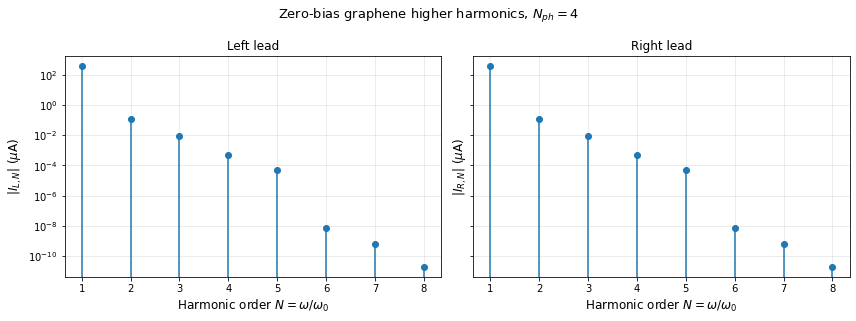

In [58]:
# ============================================================
# Cell F4-R&L: Final higher-harmonic spectrum
#          (left panel: |I_L,N|, right panel: |I_R,N|)
# ============================================================

harmonic_magnitudes_final = np.array(
    [
        final_results[N]["magnitude"]
        for N in N_values_final
    ]
)

harmonic_magnitudes_final_left = np.array(
    [
        final_results_left[N]["magnitude"]
        for N in N_values_final
    ]
)

fig, (ax_left, ax_right) = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    sharey=True
)

ax_left.stem(
    N_values_final,
    harmonic_magnitudes_final_left,
    basefmt=" "
)
ax_left.set_yscale("log")
ax_left.set_xlabel(r"Harmonic order $N=\omega/\omega_0$", fontsize=12)
ax_left.set_ylabel(r"$|I_{L,N}|$ ($\mu$A)", fontsize=12)
ax_left.set_title("Left lead")
ax_left.set_xticks(N_values_final)
ax_left.grid(alpha=0.3, which="both")

ax_right.stem(
    N_values_final,
    harmonic_magnitudes_final,
    basefmt=" "
)
ax_right.set_yscale("log")
ax_right.set_xlabel(r"Harmonic order $N=\omega/\omega_0$", fontsize=12)
ax_right.set_ylabel(r"$|I_{R,N}|$ ($\mu$A)", fontsize=12)
ax_right.set_title("Right lead")
ax_right.set_xticks(N_values_final)
ax_right.grid(alpha=0.3, which="both")

fig.suptitle(
    rf"Zero-bias graphene higher harmonics, "
    rf"$N_{{ph}}={Nph_final}$",
    fontsize=13
)

plt.tight_layout()
plt.show()

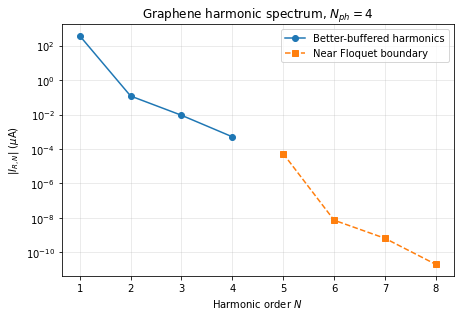

In [59]:
# ============================================================
# Cell F5: Spectrum with a conservative reliability marker
#for right lead
# ============================================================

# A practical conservative range is N <= Nph_final.
trusted_orders = N_values_final[
    N_values_final <= Nph_final
]

boundary_orders = N_values_final[
    N_values_final > Nph_final
]

plt.figure(figsize=(6.5, 4.5))

plt.semilogy(
    trusted_orders,
    harmonic_magnitudes_final[:len(trusted_orders)],
    "o-",
    label="Better-buffered harmonics"
)

if len(boundary_orders) > 0:

    plt.semilogy(
        boundary_orders,
        harmonic_magnitudes_final[len(trusted_orders):],
        "s--",
        label="Near Floquet boundary"
    )

plt.xlabel(r"Harmonic order $N$")
plt.ylabel(r"$|I_{R,N}|$ ($\mu$A)")

plt.title(
    rf"Graphene harmonic spectrum, "
    rf"$N_{{ph}}={Nph_final}$"
)

plt.xticks(N_values_final)
plt.grid(alpha=0.3, which="both")
plt.legend()

plt.tight_layout()
plt.show()